## EDA for BLS Occupation Data
#### Actions
- Feature Engineering for Tier 1 (highest) and Tier 2 (med) occupation codes
- Check occupation labels are consistent YoY
- Start some Initial Line Charts for Technology Category

#### Metrics
- % of employment market made up of technology jobs
- raw count of technology jobs over time
- shifting % of jobs over time

In [14]:
%cd analytics-applications-sp2026-final #run this if you are in Google CoLab and have cloned the repo



[Errno 2] No such file or directory: 'analytics-applications-sp2026-final #run this if you are in Google CoLab and have cloned the repo'
/root/analytics-applications-sp2026-final


In [1]:
import pandas as pd
from pathlib import Path

# Import National Employment Stats
file_path = 'national_bls_stats_cleaned.xlsx'
df = pd.read_excel(file_path)


# Exploration

In [2]:
df.head()

,Year,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,...,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY,ONE_OR_THREE
0,2024.0,99.0,U.S.,1.0,US,0.0,Cross-industry,cross-industry,1235.0,00-0000,...,37.89,60.44,29990,36730,49500,78810,125720,NaN,NaN,NaN
1,2024.0,99.0,U.S.,1.0,US,0.0,Cross-industry,cross-industry,1235.0,11-0000,...,82.5,#,57010,79900,122090,171610,#,NaN,NaN,NaN
2,2024.0,99.0,U.S.,1.0,US,0.0,Cross-industry,cross-industry,1235.0,11-1000,...,81.01,#,47510,68800,104990,168490,#,NaN,NaN,NaN
3,2024.0,99.0,U.S.,1.0,US,0.0,Cross-industry,cross-industry,1235.0,11-1010,...,#,#,73710,126080,206420,#,#,NaN,NaN,NaN
4,2024.0,99.0,U.S.,1.0,US,0.0,Cross-industry,cross-industry,1235.0,11-1011,...,#,#,73710,126080,206420,#,#,NaN,NaN,NaN


In [3]:
df.columns

Index(['Year', 'AREA', 'AREA_TITLE', 'AREA_TYPE', 'PRIM_STATE', 'NAICS',
       'NAICS_TITLE', 'I_GROUP', 'OWN_CODE', 'OCC_CODE', 'OCC_CODE_CLEANED',
       'OCC_TITLE', 'O_GROUP', 'TOT_EMP', 'EMP_PRSE', 'JOBS_1000',
       'LOC_QUOTIENT', 'PCT_TOTAL', 'PCT_RPT', 'H_MEAN', 'A_MEAN', 'MEAN_PRSE',
       'H_PCT10', 'H_PCT25', 'H_MEDIAN', 'H_PCT75', 'H_PCT90', 'A_PCT10',
       'A_PCT25', 'A_MEDIAN', 'A_PCT75', 'A_PCT90', 'ANNUAL', 'HOURLY',
       'ONE_OR_THREE'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29894 entries, 0 to 29893
Data columns (total 35 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              29893 non-null  float64
 1   AREA              8269 non-null   float64
 2   AREA_TITLE        8269 non-null   object 
 3   AREA_TYPE         8269 non-null   float64
 4   PRIM_STATE        6940 non-null   object 
 5   NAICS             8269 non-null   float64
 6   NAICS_TITLE       8269 non-null   object 
 7   I_GROUP           8269 non-null   object 
 8   OWN_CODE          8269 non-null   float64
 9   OCC_CODE          29893 non-null  object 
 10  OCC_CODE_CLEANED  29893 non-null  object 
 11  OCC_TITLE         29894 non-null  object 
 12  O_GROUP           18390 non-null  object 
 13  TOT_EMP           29880 non-null  object 
 14  EMP_PRSE          29879 non-null  object 
 15  JOBS_1000         0 non-null      float64
 16  LOC_QUOTIENT      0 non-null      float6

#### Discoveries
1. JOBS_1000, LOC_QUOTIENT, PCT_TOTAL, PCT_RPT are all null completely -- drop
2. YEAR needs to be changed to datetime
3. AREA, AREA_TITLE, AREA_TYPE, PRIM_STATE,	NAICS, NAICS_TITLE, I_GROUP, OWN_CODE all have only one value it appears in the excel, validate this then drop
4. Some renaming could help

In [5]:
# Drop completely null columns
df = df.drop(columns=['JOBS_1000','OCC_CODE', 'LOC_QUOTIENT', 'PCT_TOTAL', 'PCT_RPT'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29894 entries, 0 to 29893
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              29893 non-null  float64
 1   AREA              8269 non-null   float64
 2   AREA_TITLE        8269 non-null   object 
 3   AREA_TYPE         8269 non-null   float64
 4   PRIM_STATE        6940 non-null   object 
 5   NAICS             8269 non-null   float64
 6   NAICS_TITLE       8269 non-null   object 
 7   I_GROUP           8269 non-null   object 
 8   OWN_CODE          8269 non-null   float64
 9   OCC_CODE_CLEANED  29893 non-null  object 
 10  OCC_TITLE         29894 non-null  object 
 11  O_GROUP           18390 non-null  object 
 12  TOT_EMP           29880 non-null  object 
 13  EMP_PRSE          29879 non-null  object 
 14  H_MEAN            29879 non-null  object 
 15  A_MEAN            29879 non-null  object 
 16  MEAN_PRSE         29879 non-null  object

In [6]:
# Check unique values in single-value columns
single_value_cols = ['AREA', 'AREA_TITLE', 'AREA_TYPE', 'PRIM_STATE', 'NAICS', 'NAICS_TITLE', 'I_GROUP', 'OWN_CODE']
for col in single_value_cols:
    n_unique = df[col].nunique()
    print(f"{col}: {n_unique} unique value(s)")



AREA: 1 unique value(s)
AREA_TITLE: 1 unique value(s)
AREA_TYPE: 1 unique value(s)
PRIM_STATE: 1 unique value(s)
NAICS: 1 unique value(s)
NAICS_TITLE: 1 unique value(s)
I_GROUP: 1 unique value(s)
OWN_CODE: 1 unique value(s)


 They only show a single value to signal that this data is from the USA.

In [7]:
# Drop columns with only 1 unique value
df = df.drop(columns=single_value_cols)
print(f"\nDropped {len(single_value_cols)} columns. Remaining shape: {df.shape}")


Dropped 8 columns. Remaining shape: (29894, 22)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29894 entries, 0 to 29893
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              29893 non-null  float64
 1   OCC_CODE_CLEANED  29893 non-null  object 
 2   OCC_TITLE         29894 non-null  object 
 3   O_GROUP           18390 non-null  object 
 4   TOT_EMP           29880 non-null  object 
 5   EMP_PRSE          29879 non-null  object 
 6   H_MEAN            29879 non-null  object 
 7   A_MEAN            29879 non-null  object 
 8   MEAN_PRSE         29879 non-null  object 
 9   H_PCT10           29879 non-null  object 
 10  H_PCT25           29879 non-null  object 
 11  H_MEDIAN          29879 non-null  object 
 12  H_PCT75           29879 non-null  object 
 13  H_PCT90           29879 non-null  object 
 14  A_PCT10           29879 non-null  object 
 15  A_PCT25           29879 non-null  object 
 16  A_MEDIAN          29879 non-null  object

# Data Type Changes

- Annual and Hourly and True/False mostly null
- YEAR is datetime
- OCC_CODE_CLEANED, OCC_TITLE, O_GROUP are all text
- The rest are numericals *They need to be cleaned from 'star', '#' ,'~' text fields*

In [9]:
# Convert data types
# Text fields
df['ANNUAL'] = df['ANNUAL'].astype(str)
df['HOURLY'] = df['HOURLY'].astype(str)
df['OCC_CODE_CLEANED'] = df['OCC_CODE_CLEANED'].astype(str)
df['OCC_TITLE'] = df['OCC_TITLE'].astype(str)
df['O_GROUP'] = df['O_GROUP'].astype(str)

# Convert YEAR to datetime
df['Year'] = pd.to_datetime(df['Year'], format='%Y')

# Convert remaining numerical fields, converting strings to NaN
numeric_cols = [col for col in df.columns if col not in ['ANNUAL', 'HOURLY', 'OCC_CODE_CLEANED', 'OCC_TITLE', 'O_GROUP', 'Year']]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types after conversion:")
print(df.dtypes)

Data types after conversion:
Year                datetime64[ns]
OCC_CODE_CLEANED            object
OCC_TITLE                   object
O_GROUP                     object
TOT_EMP                    float64
EMP_PRSE                   float64
H_MEAN                     float64
A_MEAN                     float64
MEAN_PRSE                  float64
H_PCT10                    float64
H_PCT25                    float64
H_MEDIAN                   float64
H_PCT75                    float64
H_PCT90                    float64
A_PCT10                    float64
A_PCT25                    float64
A_MEDIAN                   float64
A_PCT75                    float64
A_PCT90                    float64
ANNUAL                      object
HOURLY                      object
ONE_OR_THREE               float64
dtype: object


# Feature Engineering
* [ ] Inflation adjusted annual salary
    * [ ] add CPI per year table
    * [ ] join CPI per year to table
    * [ ] new col for adjusted Salary

## Inflation Adjustments

In [10]:
# Import National Employment Stats
cpi_path = 'CPI-U_index_monthly.xlsx'
cpi_df = pd.read_excel(cpi_path)

cpi_df.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
0,1997,159.4,159.7,159.8,159.9,159.9,160.2,160.4,160.8,161.2,161.5,161.7,161.8,160.525000
1,1998,162.0,162.0,162.0,162.2,162.6,162.8,163.2,163.4,163.5,163.9,164.1,164.4,163.008333
2,1999,164.7,164.7,164.8,165.9,166.0,166.0,166.7,167.1,167.8,168.1,168.4,168.8,166.583333
3,2000,169.3,170.0,171.0,170.9,171.2,172.2,172.7,172.7,173.6,173.9,174.2,174.6,172.191667
4,2001,175.6,176.0,176.1,176.4,177.3,177.7,177.4,177.4,178.1,177.6,177.5,177.4,177.041667


In [11]:
# Convert YEAR to datetime
cpi_df['Year'] = pd.to_datetime(cpi_df['Year'], format='%Y')
cpi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Year    28 non-null     datetime64[ns]
 1   Jan     28 non-null     float64       
 2   Feb     28 non-null     float64       
 3   Mar     28 non-null     float64       
 4   Apr     28 non-null     float64       
 5   May     28 non-null     float64       
 6   Jun     28 non-null     float64       
 7   Jul     28 non-null     float64       
 8   Aug     28 non-null     float64       
 9   Sep     28 non-null     float64       
 10  Oct     28 non-null     float64       
 11  Nov     28 non-null     float64       
 12  Dec     28 non-null     float64       
 13  Annual  28 non-null     float64       
dtypes: datetime64[ns](1), float64(13)
memory usage: 3.2 KB


In [12]:
# left join CPI annual index into main df by Year
cpi_join = cpi_df[['Year', 'Annual']].rename(columns={'Annual': 'CPI'})

df = df.merge(cpi_join, on='Year', how='left')

# verify
df[['Year', 'CPI']].head()

,Year,CPI
0,2024-01-01,313.698167
1,2024-01-01,313.698167
2,2024-01-01,313.698167
3,2024-01-01,313.698167
4,2024-01-01,313.698167


In [13]:
current_CPI = df[df['Year']=='2024-01-01']['CPI'].values[0]
print(f"Current CPI (2024): {current_CPI}")

Current CPI (2024): 313.6981666666666


In [14]:
df['REAL_A_MEAN'] = df['A_MEAN'] * (current_CPI / df['CPI'])
df['REAL_A_MEDIAN'] = df['A_MEDIAN'] * (current_CPI / df['CPI'])
df['REAL_H_MEDIAN'] = df['H_MEDIAN'] * (current_CPI / df['CPI'])
df['REAL_H_MEAN'] = df['H_MEAN'] * (current_CPI / df['CPI'])
df.tail()

,Year,OCC_CODE_CLEANED,OCC_TITLE,O_GROUP,TOT_EMP,EMP_PRSE,H_MEAN,A_MEAN,MEAN_PRSE,H_PCT10,...,A_PCT75,A_PCT90,ANNUAL,HOURLY,ONE_OR_THREE,CPI,REAL_A_MEAN,REAL_A_MEDIAN,REAL_H_MEDIAN,REAL_H_MEAN
29889,1997-01-01,98799,"All Other Freight, Stock, and Material Movers,...",nan,771590.0,1.2,9.22,19170.0,0.4,5.75,...,22339.0,28184.0,nan,nan,NaN,160.525,37462.039277,34429.118831,16.552085,18.017736
29890,1997-01-01,98902,Hand Packers and Packagers,nan,962770.0,1.4,7.46,15510.0,0.3,5.36,...,17659.0,21944.0,nan,nan,NaN,160.525,30309.662451,28046.697324,13.483989,14.578342
29891,1997-01-01,98905,Vehicle Washers and Equipment Cleaners,nan,249240.0,1.3,7.46,15520.0,0.5,5.35,...,17410.0,22090.0,nan,nan,NaN,160.525,30329.204465,27519.062968,13.229943,14.578342
29892,1997-01-01,98999,"All Other Helpers, Laborers, and Material Move...",nan,1646250.0,1.3,9.39,19540.0,0.5,5.57,...,22506.0,31242.0,nan,nan,NaN,160.525,38185.093765,33858.492046,16.278497,18.349950
29893,NaT,nan,Total 1997 Employment,nan,117073130.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,nan,nan,NaN,NaN,NaN,NaN,NaN,NaN


## OCC General Codes

In [15]:
df['OCC_2DIGIT'] = df['OCC_CODE_CLEANED'].str[:2]
print(df['OCC_2DIGIT'].unique())

['00' '11' '13' '15' '17' '19' '21' '23' '25' '27' '29' '31' '33' '35'
 '37' '39' '41' '43' '45' '47' '49' '51' '53' '10' '20' '22' '24' '28'
 '32' '34' '40' '50' '55' '56' '57' '58' '59' '60' '61' '63' '65' '66'
 '67' '68' '69' '70' '72' '73' '79' '80' '81' '83' '85' '87' '89' '91'
 '92' '93' '95' '97' '98' 'na']


In [16]:
df['OCC_Last4'] = df['OCC_CODE_CLEANED'].str[-4:]
print(df['OCC_Last4'].unique())

['0000' '1000' '1010' ... '8905' '8999' 'nan']


In [17]:

import matplotlib.pyplot as plt

colors = [
    '#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78', '#2ca02c',
    '#98df8a', '#d62728', '#ff9896', '#9467bd', '#c5b0d5',
    '#8c564b', '#c49c94', '#e377c2', '#f7b6d2', '#7f7f7f',
    '#c7c7c7', '#bcbd22', '#dbdb8d', '#17becf', '#9edae5',
    '#1b9e77', '#d95f02'
]

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)


## Employment Counts and %

### Line Charts TOT EMP

In [18]:
major_occ_codes_df = df[df['O_GROUP'] == 'major'][['OCC_CODE_CLEANED', 'OCC_TITLE']].drop_duplicates(subset=['OCC_CODE_CLEANED'], keep='last').reset_index(drop=True)
display(major_occ_codes_df)

,OCC_CODE_CLEANED,OCC_TITLE
0,00-0000,All Occupations
1,11-0000,Management Occupations
2,13-0000,Business and Financial Operations Occupations
3,15-0000,Computer and Mathematical Occupations
4,17-0000,Architecture and Engineering Occupations
5,19-0000,"Life, Physical, and Social Science Occupations"
6,21-0000,Community and Social Services Occupations
7,23-0000,Legal Occupations
8,25-0000,"Education, Training, and Library Occupations"
9,27-0000,"Arts, Design, Entertainment, Sports, and Media..."


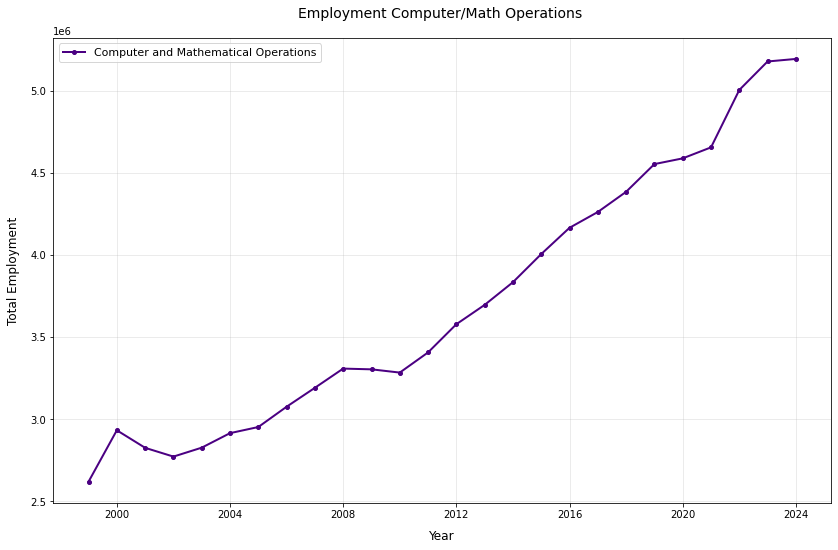

In [19]:


# Filter for both occupation codes
tech_df = df[df['OCC_CODE_CLEANED'] == '15-0000'].copy()


# Sort by Year for proper line chart
tech_df = tech_df.sort_values('Year')

# Create line chart with both lines
plt.figure(figsize=(12, 8))
plt.plot(tech_df['Year'], tech_df['TOT_EMP'], marker='o', linewidth=2, markersize=4, label='Computer and Mathematical Operations', color='#4B0082')
plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Total Employment', fontsize=12, labelpad=10)
plt.title('Employment Computer/Math Operations ', fontsize=14, pad=20)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=2.0)
plt.show()

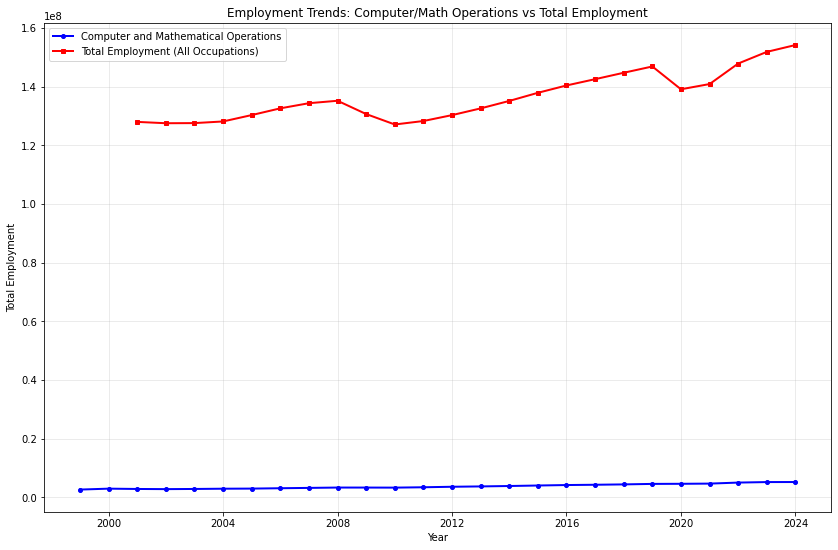

In [20]:
import matplotlib.pyplot as plt

# Filter for both occupation codes
tech_df = df[df['OCC_CODE_CLEANED'] == '15-0000'].copy()
total_df = df[df['OCC_CODE_CLEANED'] == '00-0000'].copy()

# Sort both datasets by Year
tech_df = tech_df.sort_values('Year')
total_df = total_df.sort_values('Year')

# Create line chart with both lines
plt.figure(figsize=(12, 8))
plt.plot(tech_df['Year'], tech_df['TOT_EMP'], marker='o',  linewidth=2, markersize=4, label='Computer and Mathematical Operations', color='blue')
plt.plot(total_df['Year'], total_df['TOT_EMP'], marker='s',  linewidth=2, markersize=4, label='Total Employment (All Occupations)', color='red')
plt.xlabel('Year')
plt.ylabel('Total Employment')
plt.title('Employment Trends: Computer/Math Operations vs Total Employment')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=2.0)
plt.show()

In [21]:
broad_df = df[(df['O_GROUP'] == 'major')][['Year', 'OCC_CODE_CLEANED','TOT_EMP']].copy()
broad_df = broad_df[broad_df['OCC_CODE_CLEANED'] != '00-0000'][['Year', 'OCC_CODE_CLEANED','TOT_EMP']].copy()

contingency_table = pd.crosstab(index=broad_df['Year'], columns=broad_df['OCC_CODE_CLEANED'],values=broad_df['TOT_EMP'],aggfunc='sum')

# Convert the Year index to string format 'YYYY'
contingency_table.index = contingency_table.index.strftime('%Y')

contingency_table_scaled  = contingency_table/ 1000000

# Add a new column with the sum of all codes by year
contingency_table_scaled['Total_OCC_Sum'] = contingency_table_scaled.sum(axis=1)


display(contingency_table_scaled.head())

OCC_CODE_CLEANED,11-0000,13-0000,15-0000,17-0000,19-0000,21-0000,23-0000,25-0000,27-0000,29-0000,...,37-0000,39-0000,41-0000,43-0000,45-0000,47-0000,49-0000,51-0000,53-0000,Total_OCC_Sum
Year,,,,,,,,,,,,,,,,,,,,,
1999,8.06341,4.36198,2.62008,2.50638,0.90953,1.40454,0.85832,7.34483,1.55160,6.00195,...,4.27420,2.55692,12.93813,22.56248,0.46336,5.93886,5.14021,12.62092,9.53882,127.27400
2000,7.78268,4.61927,2.93281,2.57562,1.03867,1.46900,0.89091,7.45086,1.51342,6.04121,...,4.31807,2.70051,13.50688,22.93614,0.46070,6.18736,5.31849,12.40008,9.59274,129.73898
2001,7.21236,4.67668,2.82587,2.48907,1.06773,1.52389,0.90937,7.65848,1.50879,6.11897,...,4.27534,2.80205,13.41824,22.79859,0.45305,6.23943,5.32307,11.27021,9.41066,127.98037
2002,7.09246,4.77212,2.77262,2.41126,1.07863,1.57698,0.93485,7.77247,1.50368,6.18502,...,4.26288,2.91928,13.33957,22.75457,0.45114,6.12460,5.21597,10.72667,9.39500,127.52374
2003,6.65348,4.92421,2.82701,2.37665,1.11313,1.61561,0.95151,7.83163,1.53815,6.17376,...,4.26038,2.98859,13.53418,22.67801,0.46163,6.08551,5.22608,10.48845,9.41492,127.56791


In [22]:
tot_emp_df = contingency_table_scaled #saving this table as a variable

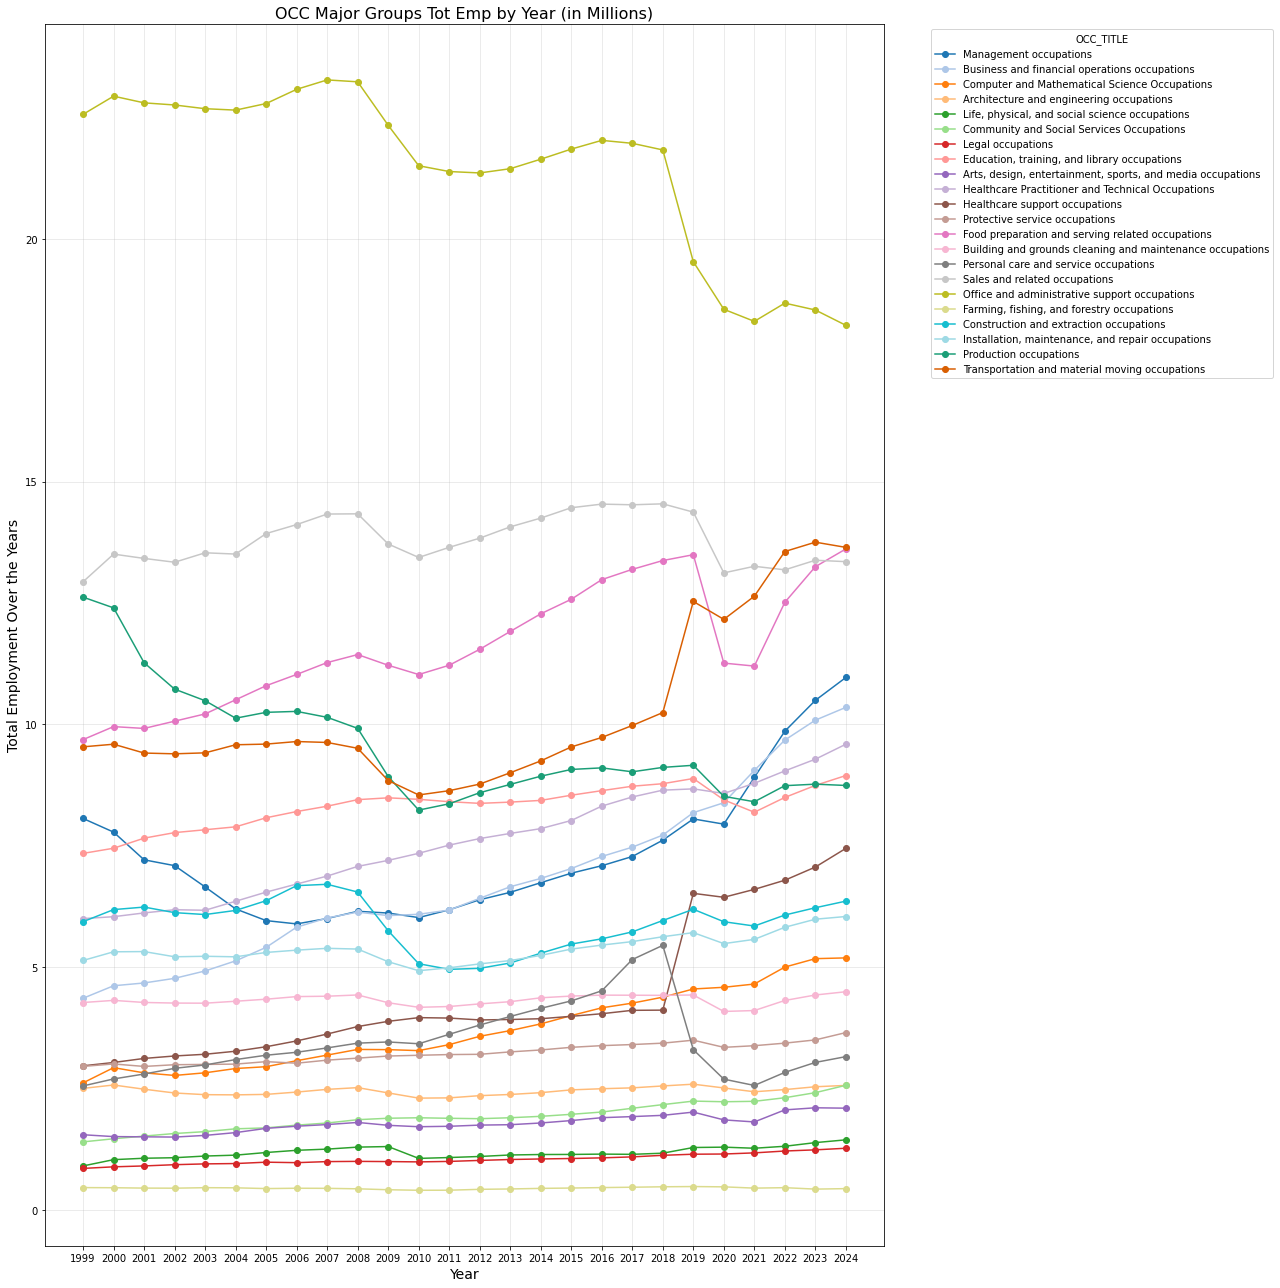

In [23]:
occ_code_to_title = df[['OCC_CODE_CLEANED', 'OCC_TITLE']].drop_duplicates().set_index('OCC_CODE_CLEANED')['OCC_TITLE'].to_dict()

# Plot each OCC_CODE_CLEANED as a line on the same chart
plt.figure(figsize=(18, 18))
for occ_code in tot_emp_df.columns[:22]:
    plt.plot(tot_emp_df.index, tot_emp_df[occ_code], marker='o', label=occ_code_to_title.get(occ_code, occ_code))

plt.xlabel('Year', fontsize=14)
plt.ylabel('Total Employment Over the Years', fontsize=14)
plt.title('OCC Major Groups Tot Emp by Year (in Millions)', fontsize=16)
plt.legend(title='OCC_TITLE', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
tot_emp_df.columns

Index(['11-0000', '13-0000', '15-0000', '17-0000', '19-0000', '21-0000',
       '23-0000', '25-0000', '27-0000', '29-0000', '31-0000', '33-0000',
       '35-0000', '37-0000', '39-0000', '41-0000', '43-0000', '45-0000',
       '47-0000', '49-0000', '51-0000', '53-0000', 'Total_OCC_Sum'],
      dtype='object', name='OCC_CODE_CLEANED')

### Heatmaps TOT EMP

In [26]:
import seaborn as sns

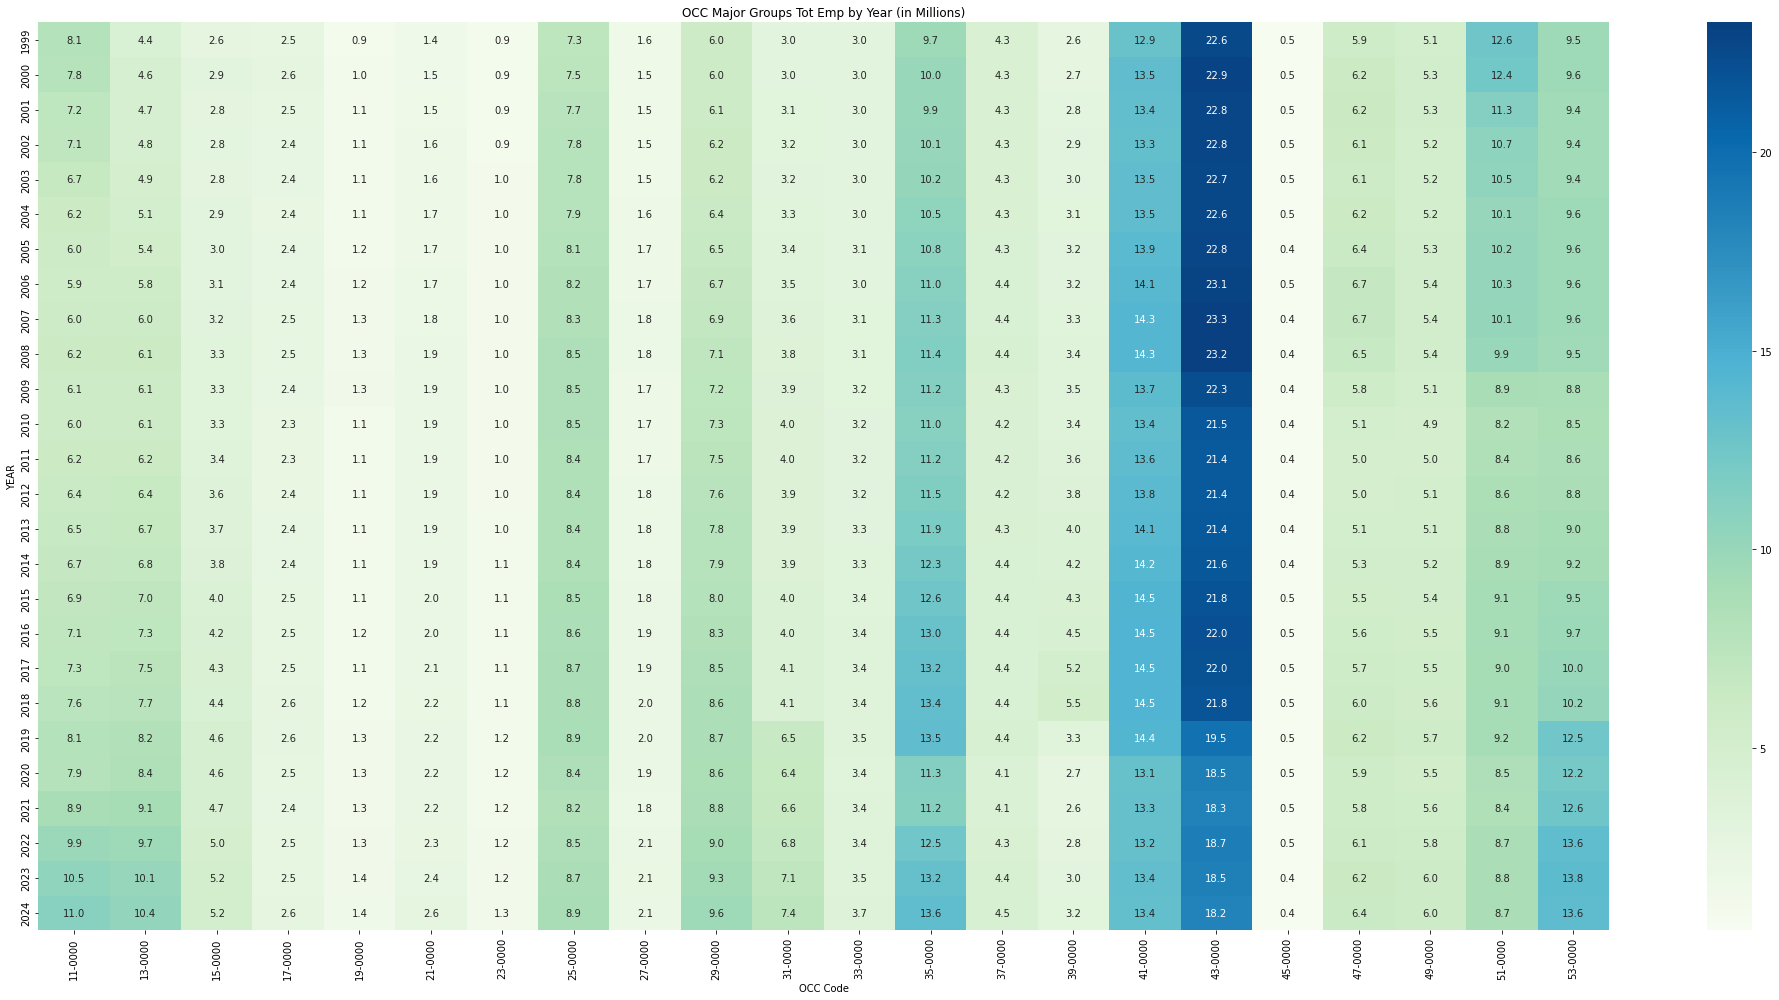

In [27]:

plt.figure(figsize=(28, 14))
heatmap_data = tot_emp_df.drop(columns=['Total_OCC_Sum'])


sns.heatmap(heatmap_data, annot=True, cmap='GnBu', fmt='.1f')
plt.title('OCC Major Groups Tot Emp by Year (in Millions)')
plt.xlabel('OCC Code') # Changed label back to 'OCC Code'
plt.ylabel('YEAR')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [28]:
display(major_occ_codes_df)

,OCC_CODE_CLEANED,OCC_TITLE
0,00-0000,All Occupations
1,11-0000,Management Occupations
2,13-0000,Business and Financial Operations Occupations
3,15-0000,Computer and Mathematical Occupations
4,17-0000,Architecture and Engineering Occupations
5,19-0000,"Life, Physical, and Social Science Occupations"
6,21-0000,Community and Social Services Occupations
7,23-0000,Legal Occupations
8,25-0000,"Education, Training, and Library Occupations"
9,27-0000,"Arts, Design, Entertainment, Sports, and Media..."


> [x] **TODO** Need to change this to % of the total market for each year so sum each row and divide: % of row total

In [29]:
tot_emp_df.head()

OCC_CODE_CLEANED,11-0000,13-0000,15-0000,17-0000,19-0000,21-0000,23-0000,25-0000,27-0000,29-0000,...,37-0000,39-0000,41-0000,43-0000,45-0000,47-0000,49-0000,51-0000,53-0000,Total_OCC_Sum
Year,,,,,,,,,,,,,,,,,,,,,
1999,8.06341,4.36198,2.62008,2.50638,0.90953,1.40454,0.85832,7.34483,1.55160,6.00195,...,4.27420,2.55692,12.93813,22.56248,0.46336,5.93886,5.14021,12.62092,9.53882,127.27400
2000,7.78268,4.61927,2.93281,2.57562,1.03867,1.46900,0.89091,7.45086,1.51342,6.04121,...,4.31807,2.70051,13.50688,22.93614,0.46070,6.18736,5.31849,12.40008,9.59274,129.73898
2001,7.21236,4.67668,2.82587,2.48907,1.06773,1.52389,0.90937,7.65848,1.50879,6.11897,...,4.27534,2.80205,13.41824,22.79859,0.45305,6.23943,5.32307,11.27021,9.41066,127.98037
2002,7.09246,4.77212,2.77262,2.41126,1.07863,1.57698,0.93485,7.77247,1.50368,6.18502,...,4.26288,2.91928,13.33957,22.75457,0.45114,6.12460,5.21597,10.72667,9.39500,127.52374
2003,6.65348,4.92421,2.82701,2.37665,1.11313,1.61561,0.95151,7.83163,1.53815,6.17376,...,4.26038,2.98859,13.53418,22.67801,0.46163,6.08551,5.22608,10.48845,9.41492,127.56791


## Line Charts % Market

In [30]:
# Create percent_of_market_df by dividing each OCC code column by 'Total_OCC_Sum'
percent_of_market_df = tot_emp_df.drop(columns=['Total_OCC_Sum']).div(tot_emp_df['Total_OCC_Sum'], axis=0) * 100

# Display the head of the new DataFrame
display(percent_of_market_df.head())

OCC_CODE_CLEANED,11-0000,13-0000,15-0000,17-0000,19-0000,21-0000,23-0000,25-0000,27-0000,29-0000,...,35-0000,37-0000,39-0000,41-0000,43-0000,45-0000,47-0000,49-0000,51-0000,53-0000
Year,,,,,,,,,,,,,,,,,,,,,
1999,6.335473,3.427236,2.058614,1.969279,0.714624,1.103556,0.674388,5.770880,1.219102,4.715771,...,7.611900,3.358266,2.008988,10.165572,17.727486,0.364065,4.666200,4.038696,9.916338,7.494712
2000,5.998721,3.560433,2.260547,1.985232,0.800584,1.132273,0.686694,5.742962,1.166511,4.656434,...,7.673145,3.328275,2.081495,10.410811,17.678681,0.355098,4.769083,4.099377,9.557713,7.393877
2001,5.635521,3.654217,2.208050,1.944884,0.834292,1.190722,0.710554,5.984105,1.178923,4.781179,...,7.749360,3.340622,2.189437,10.484608,17.814130,0.354000,4.875302,4.159286,8.806202,7.353206
2002,5.561678,3.742142,2.174199,1.890832,0.845827,1.236617,0.733079,6.094920,1.179137,4.850093,...,7.894279,3.342813,2.289205,10.460460,17.843399,0.353769,4.802714,4.090195,8.411508,7.367256
2003,5.215638,3.860070,2.216082,1.863047,0.872578,1.266471,0.745885,6.139185,1.205750,4.839587,...,8.008770,3.339696,2.342744,10.609392,17.777206,0.361870,4.770408,4.096704,8.221856,7.380320


### Heatmaps % Market

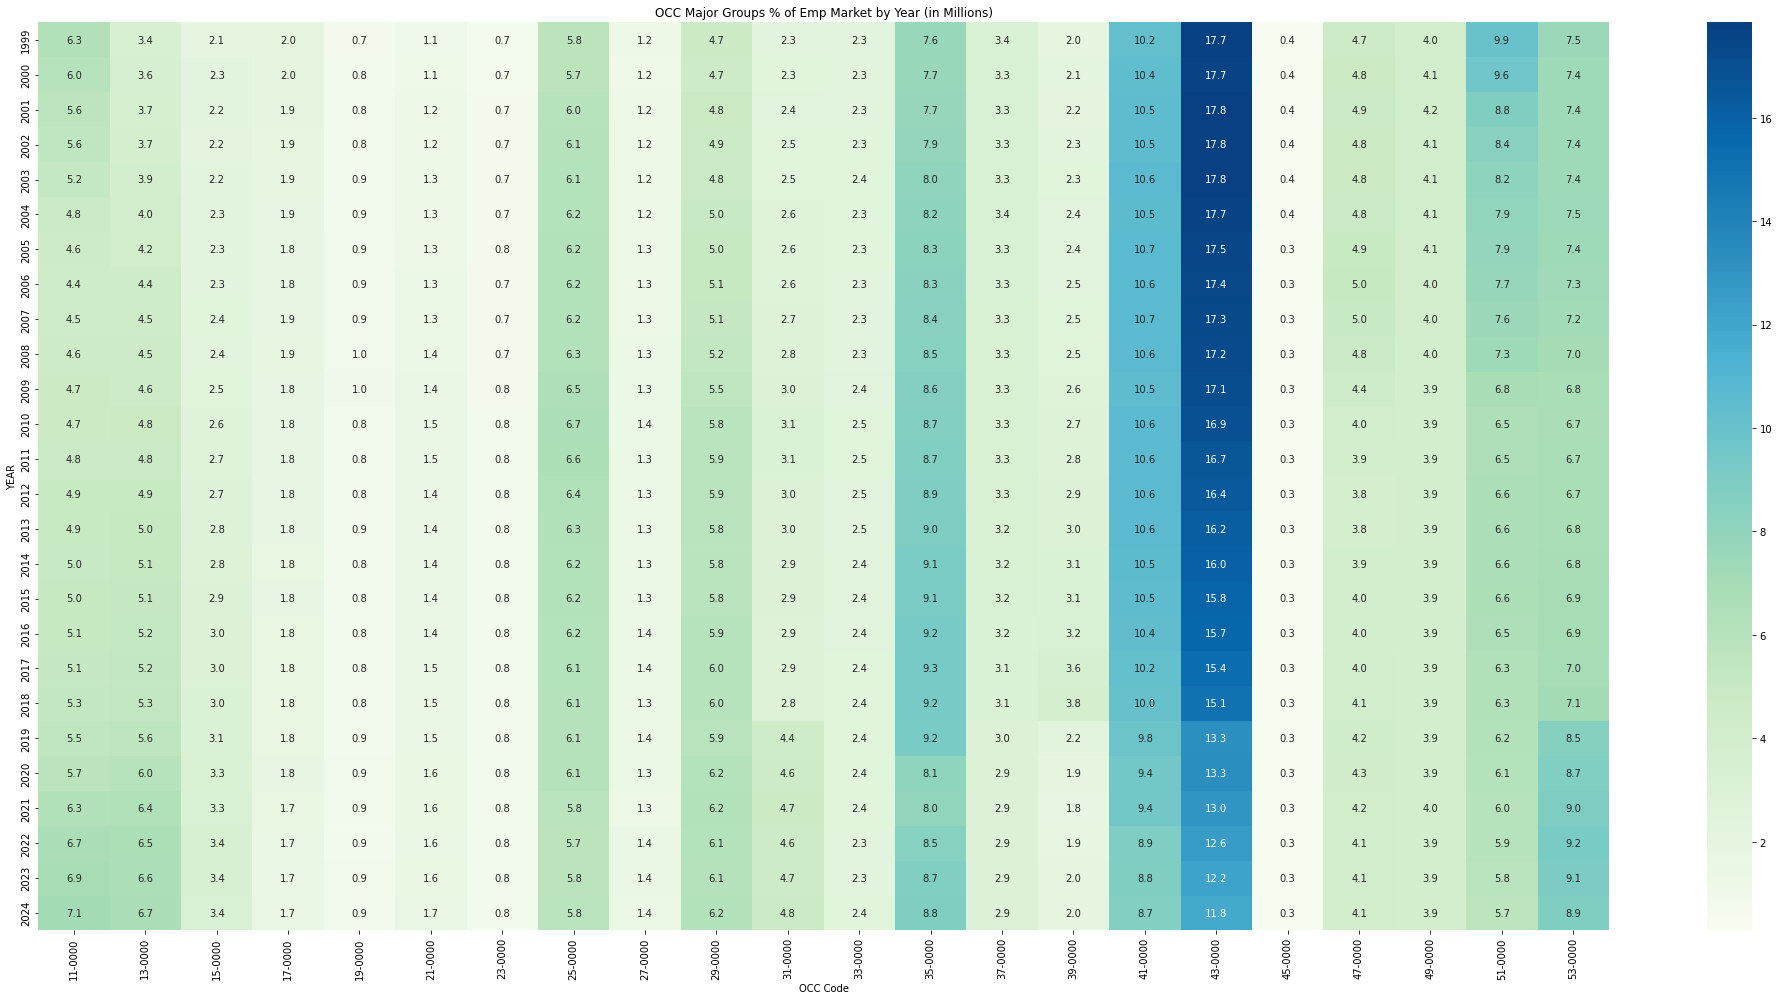

In [31]:
plt.figure(figsize=(28, 14))
heatmap_data = percent_of_market_df


sns.heatmap(heatmap_data, annot=True, cmap='GnBu', fmt='.1f')
plt.title('OCC Major Groups % of Emp Market by Year (in Millions)')
plt.xlabel('OCC Code')
plt.ylabel('YEAR')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Stacked Bars % Market

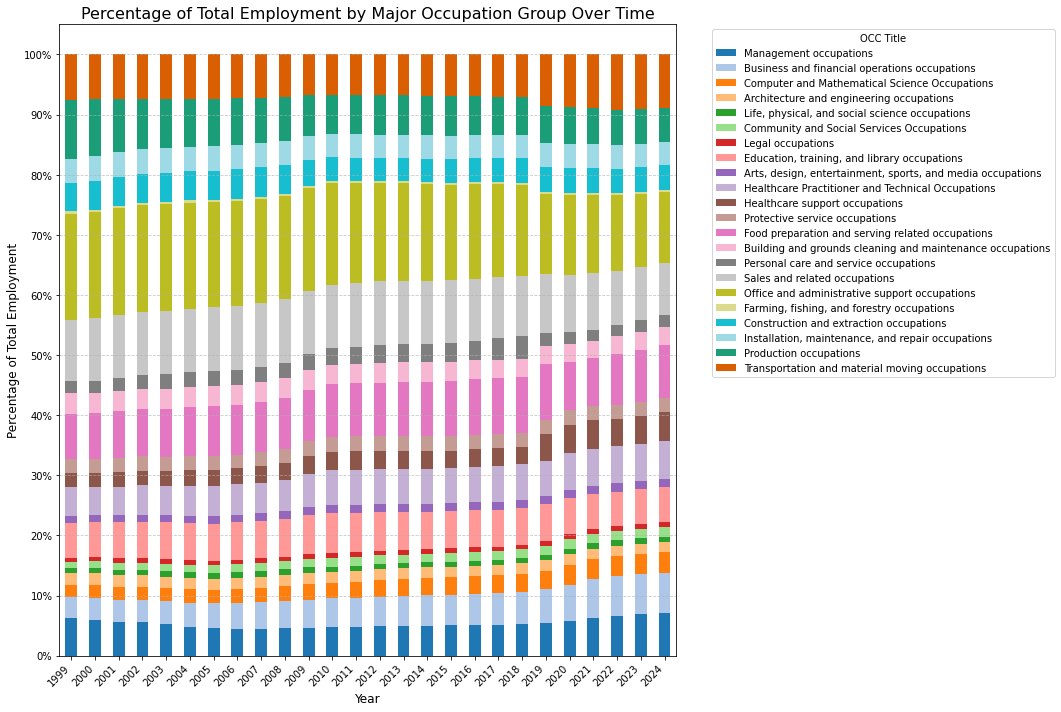

In [32]:
import matplotlib.pyplot as plt

# Rename columns for better legend labels using the existing occ_code_to_title mapping
percent_of_market_df_renamed = percent_of_market_df.rename(columns=occ_code_to_title)

fig, ax = plt.subplots(figsize=(15, 10))

percent_of_market_df_renamed.plot(
    kind='bar',
    stacked=True,
    ax=ax
)

plt.title('Percentage of Total Employment by Major Occupation Group Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage of Total Employment', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(range(0, 101, 10), [f'{i}%' for i in range(0, 101, 10)]) # Format y-axis as percentage
plt.legend(title='OCC Title', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Stacked Area Chart for Percentage of Total Employment

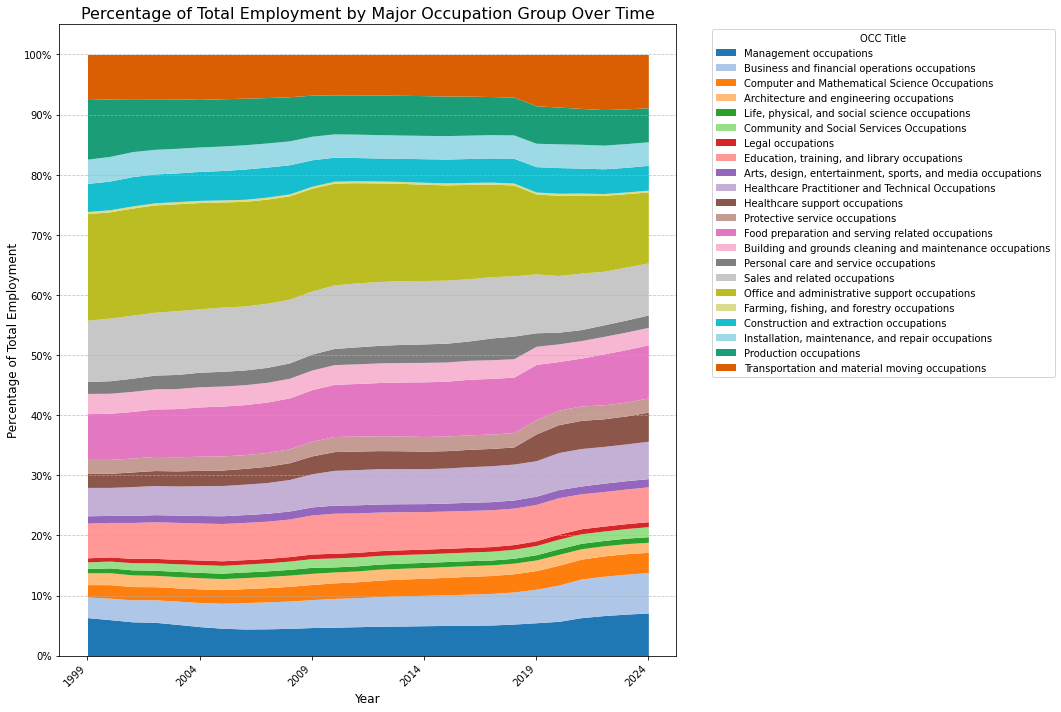

In [33]:
import matplotlib.pyplot as plt

# Rename columns for better legend labels using the existing occ_code_to_title mapping
percent_of_market_df_renamed = percent_of_market_df.rename(columns=occ_code_to_title)

fig, ax = plt.subplots(figsize=(15, 10))

# Plot as a stacked area chart
percent_of_market_df_renamed.plot(
    kind='area',
    stacked=True,
    ax=ax,
    linewidth=0 # Remove line borders for a cleaner stacked area look
)

plt.title('Percentage of Total Employment by Major Occupation Group Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage of Total Employment', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(range(0, 101, 10), [f'{i}%' for i in range(0, 101, 10)]) # Format y-axis as percentage
plt.legend(title='OCC Title', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Linear Regression % Market Slope and r2

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Initialize a list to store the regression results
market_share_regression_results = []

# Convert the Year index to numerical for regression
numeric_years_market_share = percent_of_market_df.index.astype(int).values.reshape(-1, 1)

# Loop through each occupation code column in percent_of_market_df
# Exclude 'Total_OCC_Sum' if it somehow ended up here, though it shouldn't for this df
for occ_code in percent_of_market_df.columns:
    # Extract the percentage data for the current occupation code
    y_market_share = percent_of_market_df[occ_code].values

    # Create a DataFrame for convenience to handle NaN values across X and y
    temp_df_market_share = pd.DataFrame({'Year': numeric_years_market_share.flatten(), 'Market_Share': y_market_share})
    temp_df_market_share = temp_df_market_share.dropna() # Drop rows with NaN values (e.g., if data is missing)

    # If after dropping NaNs, there's not enough data for regression, skip
    if len(temp_df_market_share) < 2:
        market_share_regression_results.append({
            'OCC_CODE_CLEANED': occ_code,
            'Slope (Annual % Change)': np.nan,
            'R-squared': np.nan
        })
        continue

    # Prepare X (independent variable - Year) and y (dependent variable - Market Share)
    X_market_share_reg = temp_df_market_share['Year'].values.reshape(-1, 1)
    y_market_share_reg = temp_df_market_share['Market_Share'].values

    # Create and fit the linear regression model
    model_market_share = LinearRegression()
    model_market_share.fit(X_market_share_reg, y_market_share_reg)

    # Get the slope (coefficient) and R-squared value
    slope_market_share = model_market_share.coef_[0] # The slope represents the average annual change in market share
    r_squared_market_share = r2_score(y_market_share_reg, model_market_share.predict(X_market_share_reg))

    # Store the results
    market_share_regression_results.append({
        'OCC_CODE_CLEANED': occ_code,
        'Slope (Annual % Change)': slope_market_share,
        'R-squared': r_squared_market_share
    })

# Convert the results list to a DataFrame
market_share_regression_df = pd.DataFrame(market_share_regression_results)

occ_titles = (
    df[['OCC_CODE_CLEANED', 'OCC_TITLE']]
    .drop_duplicates(subset=['OCC_CODE_CLEANED'])
    .set_index('OCC_CODE_CLEANED')
)

# Merge with OCC_TITLE for better readability (using the existing occ_code_to_title mapping)
market_share_regression_df = market_share_regression_df.merge(occ_titles, on='OCC_CODE_CLEANED', how='left')

# Sort the results by 'Slope (Annual % Change)' in descending order to see top growth occupations
market_share_regression_df_sorted = market_share_regression_df.sort_values(by='Slope (Annual % Change)', ascending=False)

print("Linear Regression Results for Annual % Change in Job Market Share:")
print("----------------------------------------------------------------------")
display(market_share_regression_df_sorted)

# Further analysis could involve filtering for high R-squared values to find reliable trends
# For example, filter for R-squared > 0.5 to only consider models with moderate to high predictive strength
print("\nOccupations with strong predictive trends (R-squared > 0.5) and highest growth in market share:")
print("------------------------------------------------------------------------------------------------")
high_r_squared_market_share_growth = market_share_regression_df_sorted[market_share_regression_df_sorted['R-squared'] > 0.5]
display(high_r_squared_market_share_growth)

Linear Regression Results for Annual % Change in Job Market Share:
----------------------------------------------------------------------


,OCC_CODE_CLEANED,Slope (Annual % Change),R-squared,OCC_TITLE
1,13-0000,0.124106,0.958716,Business and Financial Operations Occupations
10,31-0000,0.093848,0.725861,Healthcare Support Occupations
9,29-0000,0.067551,0.918166,Healthcare Practitioners and Technical Occupat...
21,53-0000,0.058341,0.299695,Transportation and Material Moving Occupations
2,15-0000,0.056112,0.976806,Computer and Mathematical Occupations
12,35-0000,0.042917,0.397418,Food Preparation and Serving Related Occupations
0,11-0000,0.041628,0.170396,Management Occupations
5,21-0000,0.018312,0.903593,Community and Social Service Occupations
8,27-0000,0.007155,0.673228,"Arts, Design, Entertainment, Sports, and Media..."
14,39-0000,0.006487,0.008965,Personal Care and Service Occupations



Occupations with strong predictive trends (R-squared > 0.5) and highest growth in market share:
------------------------------------------------------------------------------------------------


,OCC_CODE_CLEANED,Slope (Annual % Change),R-squared,OCC_TITLE
1,13-0000,0.124106,0.958716,Business and Financial Operations Occupations
10,31-0000,0.093848,0.725861,Healthcare Support Occupations
9,29-0000,0.067551,0.918166,Healthcare Practitioners and Technical Occupat...
2,15-0000,0.056112,0.976806,Computer and Mathematical Occupations
5,21-0000,0.018312,0.903593,Community and Social Service Occupations
8,27-0000,0.007155,0.673228,"Arts, Design, Entertainment, Sports, and Media..."
6,23-0000,0.004853,0.822423,Legal Occupations
17,45-0000,-0.002015,0.613417,"Farming, Fishing, and Forestry Occupations"
19,49-0000,-0.008534,0.549834,"Installation, Maintenance, and Repair Occupations"
3,17-0000,-0.009818,0.862073,Architecture and Engineering Occupations


## Salaries

### Line Charts

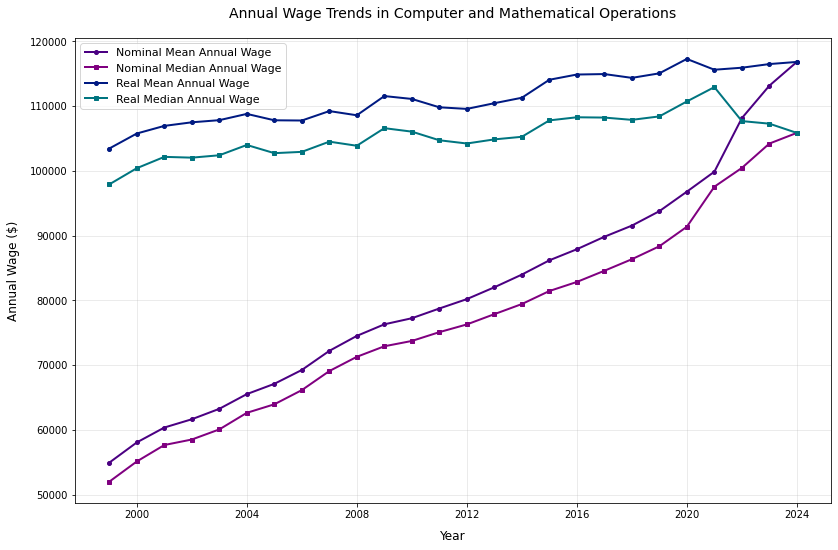

In [36]:
import matplotlib.pyplot as plt

# Filter for Computer and Mathematical Operations
tech_df = df[df['OCC_CODE_CLEANED'] == '15-0000'].copy()

# Sort by Year
tech_df = tech_df.sort_values('Year')

# Create line chart for A_MEAN and A_MEDIAN
plt.figure(figsize=(12, 8))
plt.plot(tech_df['Year'], tech_df['A_MEAN'], marker='o', linewidth=2, markersize=4, label='Nominal Mean Annual Wage', color='#4B0082')
plt.plot(tech_df['Year'], tech_df['A_MEDIAN'], marker='s', linewidth=2, markersize=4, label='Nominal Median Annual Wage', color='#800080')
plt.plot(tech_df['Year'], tech_df['REAL_A_MEAN'], marker='o', linewidth=2, markersize=4, label='Real Mean Annual Wage', color="#001A82")
plt.plot(tech_df['Year'], tech_df['REAL_A_MEDIAN'], marker='s', linewidth=2, markersize=4, label='Real Median Annual Wage', color="#007580")
plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Annual Wage ($)', fontsize=12, labelpad=10)
plt.title('Annual Wage Trends in Computer and Mathematical Operations', fontsize=14, pad=20)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=2.0)
plt.show()

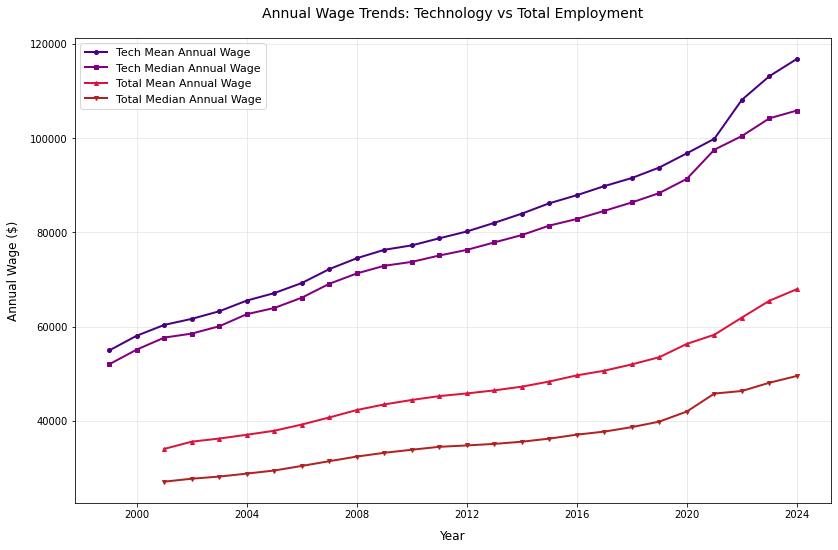

In [37]:
import matplotlib.pyplot as plt

# Filter for both occupation codes
tech_df = df[df['OCC_CODE_CLEANED'] == '15-0000'].copy()
total_df = df[df['OCC_CODE_CLEANED'] == '00-0000'].copy()

# Sort both datasets by Year
tech_df = tech_df.sort_values('Year')
total_df = total_df.sort_values('Year')

# Create line chart for A_MEAN and A_MEDIAN
plt.figure(figsize=(12, 8))
plt.plot(tech_df['Year'], tech_df['A_MEAN'], marker='o', linewidth=2, markersize=4, label='Tech Mean Annual Wage', color='#4B0082')
plt.plot(tech_df['Year'], tech_df['A_MEDIAN'], marker='s', linewidth=2, markersize=4, label='Tech Median Annual Wage', color='#800080')
plt.plot(total_df['Year'], total_df['A_MEAN'], marker='^', linewidth=2, markersize=4, label='Total Mean Annual Wage', color='#DC143C')
plt.plot(total_df['Year'], total_df['A_MEDIAN'], marker='v', linewidth=2, markersize=4, label='Total Median Annual Wage', color='#B22222')
plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Annual Wage ($)', fontsize=12, labelpad=10)
plt.title('Annual Wage Trends: Technology vs Total Employment', fontsize=14, pad=20)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=2.0)
plt.show()

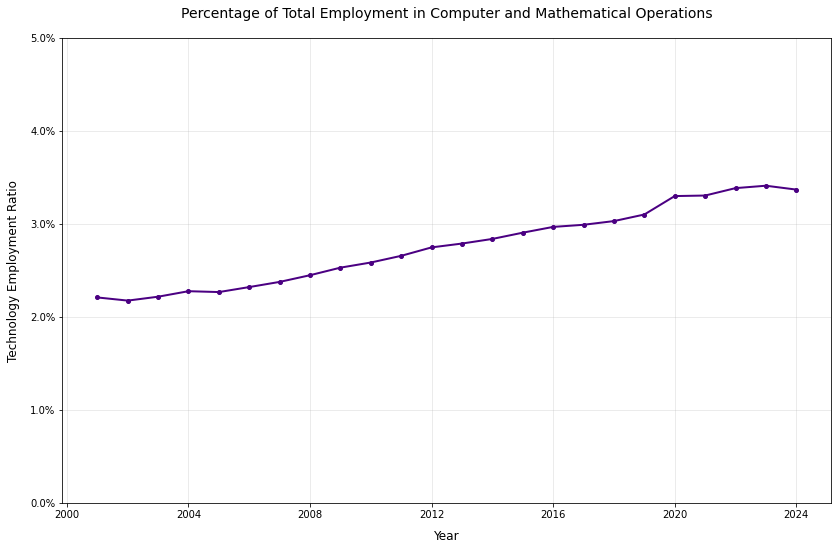

Technology Employment as % of Total Employment:
      Year  tech_ratio
2001-01-01    0.022080
2002-01-01    0.021742
2003-01-01    0.022161
2004-01-01    0.022753
2005-01-01    0.022660
2006-01-01    0.023198
2007-01-01    0.023753
2008-01-01    0.024472
2009-01-01    0.025287
2010-01-01    0.025838
2011-01-01    0.026557
2012-01-01    0.027464
2013-01-01    0.027877
2014-01-01    0.028374
2015-01-01    0.029045
2016-01-01    0.029666
2017-01-01    0.029895
2018-01-01    0.030292
2019-01-01    0.030998
2020-01-01    0.032981
2021-01-01    0.033039
2022-01-01    0.033836
2023-01-01    0.034095
2024-01-01    0.033679


In [38]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Filter for both occupation codes
tech_df = df[df['OCC_CODE_CLEANED'] == '15-0000'][['Year', 'TOT_EMP']].copy()
total_df = df[df['OCC_CODE_CLEANED'] == '00-0000'][['Year', 'TOT_EMP']].copy()

# Merge on Year to get both values for each year
merged_df = pd.merge(tech_df, total_df, on='Year', suffixes=('_tech', '_total'))

# Calculate the ratio (tech employment / total employment)
merged_df['tech_ratio'] = merged_df['TOT_EMP_tech'] / merged_df['TOT_EMP_total']

# Sort by Year
merged_df = merged_df.sort_values('Year')

# Create line chart
plt.figure(figsize=(12, 8))
plt.plot(merged_df['Year'], merged_df['tech_ratio'], marker='o', linewidth=2, markersize=4, color='#4B0082')
plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Technology Employment Ratio', fontsize=12, labelpad=10)
plt.title('Percentage of Total Employment in Computer and Mathematical Operations', fontsize=14, pad=20)
plt.ylim(0, .05)
# Format y-axis as percentage
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.1f}%'))
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=2.0)
plt.show()

# Display the ratio values
print("Technology Employment as % of Total Employment:")
print(merged_df[['Year', 'tech_ratio']].to_string(index=False))

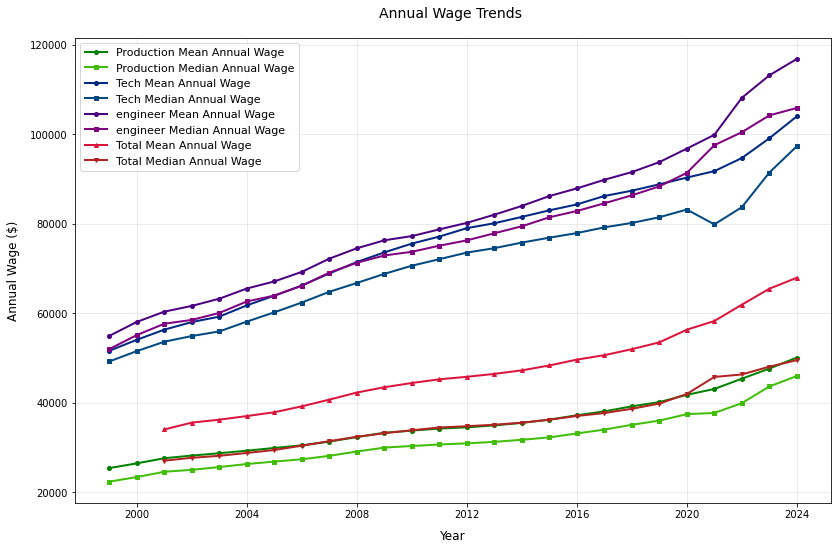

In [39]:
import matplotlib.pyplot as plt

# Filter for both occupation codes
eng_df = df[df['OCC_CODE_CLEANED'] == '15-0000'].copy()
tech_df = df[df['OCC_CODE_CLEANED'] == '17-0000'].copy()
prod_df = df[df['OCC_CODE_CLEANED'] == '51-0000'].copy()

total_df = df[df['OCC_CODE_CLEANED'] == '00-0000'].copy()

# Sort both datasets by Year
prod_df = prod_df.sort_values('Year')

tech_df = tech_df.sort_values('Year')
eng_df = eng_df.sort_values('Year')
total_df = total_df.sort_values('Year')

# Create line chart for A_MEAN and A_MEDIAN
plt.figure(figsize=(12, 8))

plt.plot(prod_df['Year'], prod_df['A_MEAN'], marker='o', linewidth=2, markersize=4, label='Production Mean Annual Wage', color="#008200")
plt.plot(prod_df['Year'], prod_df['A_MEDIAN'], marker='s', linewidth=2, markersize=4, label='Production Median Annual Wage', color="#40BE0A")
plt.plot(tech_df['Year'], tech_df['A_MEAN'], marker='o', linewidth=2, markersize=4, label='Tech Mean Annual Wage', color="#002782")
plt.plot(tech_df['Year'], tech_df['A_MEDIAN'], marker='s', linewidth=2, markersize=4, label='Tech Median Annual Wage', color="#004980")
plt.plot(eng_df['Year'], eng_df['A_MEAN'], marker='o', linewidth=2, markersize=4, label='engineer Mean Annual Wage', color='#4B0082')
plt.plot(eng_df['Year'], eng_df['A_MEDIAN'], marker='s', linewidth=2, markersize=4, label='engineer Median Annual Wage', color='#800080')
plt.plot(total_df['Year'], total_df['A_MEAN'], marker='^', linewidth=2, markersize=4, label='Total Mean Annual Wage', color='#DC143C')
plt.plot(total_df['Year'], total_df['A_MEDIAN'], marker='v', linewidth=2, markersize=4, label='Total Median Annual Wage', color='#B22222')

plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Annual Wage ($)', fontsize=12, labelpad=10)
plt.title('Annual Wage Trends ', fontsize=14, pad=20)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout(pad=2.0)
plt.show()

In [40]:
import seaborn as sns

In [41]:
broad_df = df[df['O_GROUP'] == 'major'][['Year', 'OCC_CODE_CLEANED','TOT_EMP']].copy()
broad_df = broad_df[broad_df['OCC_CODE_CLEANED'] != '00-0000'][['Year', 'OCC_CODE_CLEANED','TOT_EMP']].copy()


### Heatmaps

> [x] **TODO** Fix Formatting labels

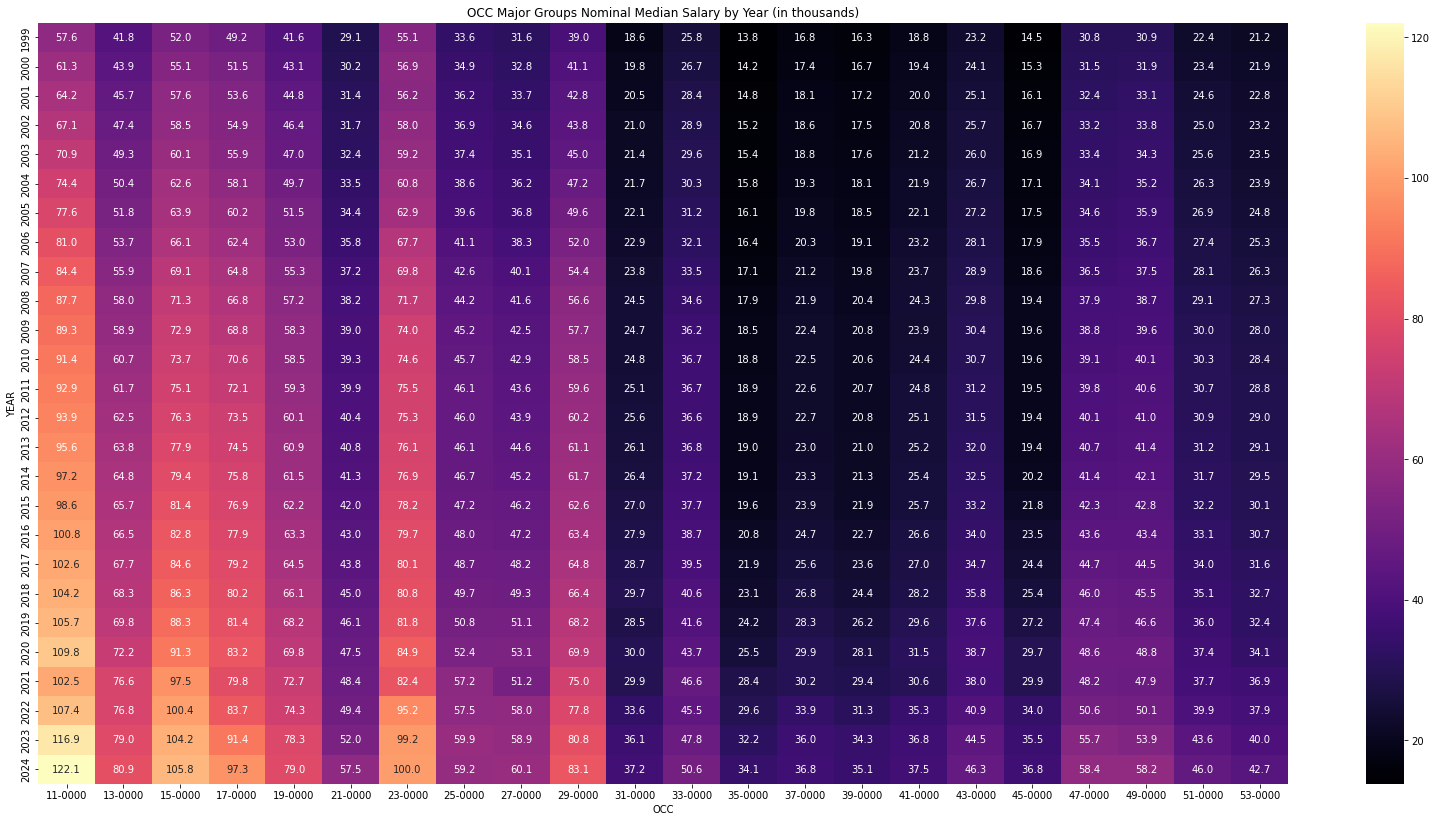

In [42]:
# Nominal Annual Median Salaries by OCC Major Group and Year
broad_df = df[df['O_GROUP'] == 'major'][['Year', 'OCC_CODE_CLEANED','A_MEDIAN']].copy()
broad_df = broad_df[broad_df['OCC_CODE_CLEANED'] != '00-0000'][['Year', 'OCC_CODE_CLEANED','A_MEDIAN']].copy()

contingency_table = pd.crosstab(index=broad_df['Year'], columns=broad_df['OCC_CODE_CLEANED'],values=broad_df['A_MEDIAN'],aggfunc='sum')

# Convert the Year index to string format 'YYYY'
contingency_table.index = contingency_table.index.strftime('%Y')

# Scale values to thousands for annotation
contingency_table_scaled = contingency_table / 1000

plt.figure(figsize=(28, 14))
sns.heatmap(contingency_table_scaled, annot=True, cmap='magma', fmt='.1f')
plt.title('OCC Major Groups Nominal Median Salary by Year (in thousands)')
plt.xlabel('OCC')
plt.ylabel('YEAR')
plt.show()


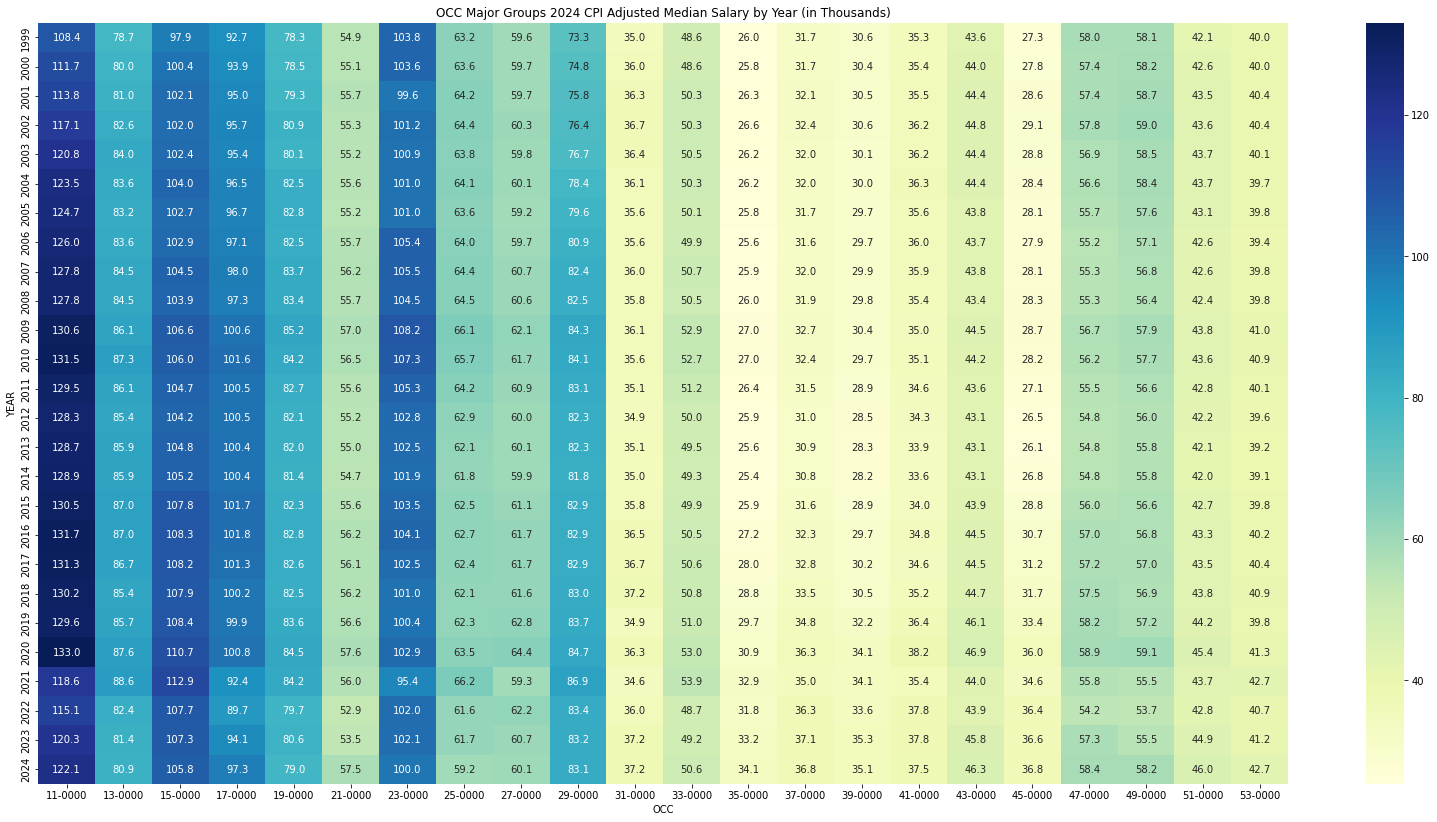

In [43]:
# Real Adjusted 2024 Dollars Annual Median Salaries by OCC Major Group and Year
broad_df = df[df['O_GROUP'] == 'major'][['Year', 'OCC_CODE_CLEANED','REAL_A_MEDIAN']].copy()
broad_df = broad_df[broad_df['OCC_CODE_CLEANED'] != '00-0000'][['Year', 'OCC_CODE_CLEANED','REAL_A_MEDIAN']].copy()

contingency_table = pd.crosstab(index=broad_df['Year'], columns=broad_df['OCC_CODE_CLEANED'],values=broad_df['REAL_A_MEDIAN'],aggfunc='sum')

# Convert the Year index to string format 'YYYY'
contingency_table.index = contingency_table.index.strftime('%Y')

# Scale values to thousands for annotation
contingency_table_scaled = contingency_table / 1000

plt.figure(figsize=(28, 14))
sns.heatmap(contingency_table_scaled, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('OCC Major Groups 2024 CPI Adjusted Median Salary by Year (in Thousands)')
plt.xlabel('OCC')
plt.ylabel('YEAR')
plt.show()


### Adjusted Line Charts

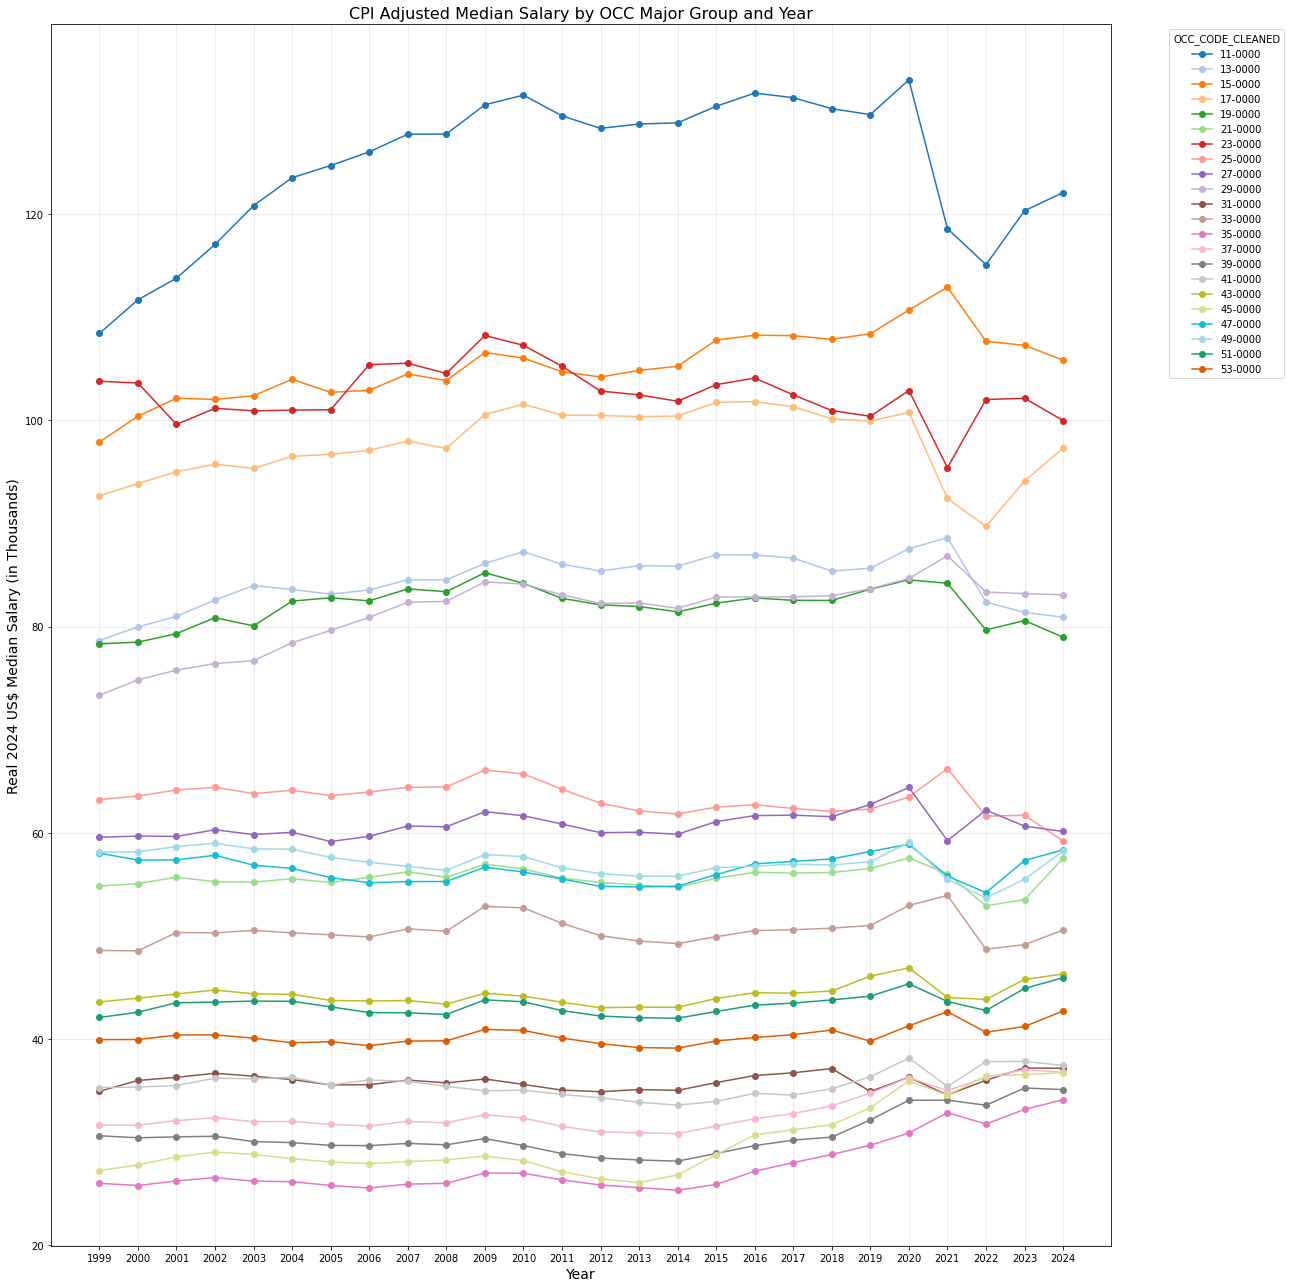

In [44]:
# Plot each OCC_CODE_CLEANED as a line on the same chart
plt.figure(figsize=(18, 18))
for occ_code in contingency_table_scaled.columns:
    plt.plot(contingency_table_scaled.index, contingency_table_scaled[occ_code], marker='o', label=occ_code)

plt.xlabel('Year', fontsize=14)
plt.ylabel('Real 2024 US$ Median Salary (in Thousands)', fontsize=14)
plt.title('CPI Adjusted Median Salary by OCC Major Group and Year', fontsize=16)
plt.legend(title='OCC_CODE_CLEANED', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
contingency_table_scaled.head()

OCC_CODE_CLEANED,11-0000,13-0000,15-0000,17-0000,19-0000,21-0000,23-0000,25-0000,27-0000,29-0000,...,35-0000,37-0000,39-0000,41-0000,43-0000,45-0000,47-0000,49-0000,51-0000,53-0000
Year,,,,,,,,,,,,,,,,,,,,,
1999,108.430658,78.658364,97.903958,92.687686,78.338232,54.855593,103.798157,63.235524,59.582251,73.347936,...,26.024864,31.655425,30.638534,35.308698,43.613304,27.267731,58.038084,58.132241,42.106799,39.960031
2000,111.694340,79.976864,100.399202,93.877171,78.501209,55.091125,103.623782,63.580696,59.700270,74.839398,...,25.814856,31.662822,30.442219,35.361069,43.978166,27.800614,57.368370,58.188179,42.611819,39.970214
2001,113.790706,81.010761,102.149396,95.026403,79.327467,55.708187,99.615595,64.160098,59.659500,75.783689,...,26.259394,32.106627,30.529646,35.508654,44.385817,28.598287,57.391482,58.667242,43.535311,40.399067
2002,117.061273,82.581217,102.027480,95.748866,80.872038,55.269245,101.172891,64.425558,60.309577,76.424687,...,26.579467,32.387185,30.590803,36.224116,44.770007,29.056031,57.833013,59.001532,43.601487,40.427299
2003,120.824941,83.982455,102.395173,95.354013,80.078277,55.238155,100.928975,63.813709,59.841335,76.702612,...,26.238124,32.000623,30.074107,36.160533,44.395110,28.829543,56.874842,58.460381,43.696109,40.098809


In [52]:
# Calculate relative % change from 1999 for each OCC_CODE_CLEANED in contingency_table_scaled
relative_change_df = contingency_table_scaled.copy()

# Get the 1999 values for each column
base_1999 = contingency_table_scaled.loc['1999']

# Calculate relative % change from 1999 for each year and occupation code
relative_change_df = (contingency_table_scaled / base_1999 - 1) * 100

# Display the new dataframe
relative_change_df.tail()

OCC_CODE_CLEANED,11-0000,13-0000,15-0000,17-0000,19-0000,21-0000,23-0000,25-0000,27-0000,29-0000,...,35-0000,37-0000,39-0000,41-0000,43-0000,45-0000,47-0000,49-0000,51-0000,53-0000
Year,,,,,,,,,,,,,,,,,,,,,
2020,22.672204,11.313313,13.073925,8.729303,7.916257,4.980752,-0.865833,0.382622,8.103692,15.440185,...,18.742413,14.619316,11.224765,8.114268,7.589658,31.862928,1.500158,1.627612,7.755085,3.354154
2021,9.381824,12.693543,15.336773,-0.279653,7.494149,2.164369,-8.064985,4.754339,-0.538841,18.437771,...,26.332520,10.590783,11.276282,0.328661,0.999905,26.772806,-3.836700,-4.530145,3.678712,6.786121
2022,6.142390,4.736345,9.977769,-3.194091,1.715894,-3.499710,-1.710103,-2.539275,4.408081,13.649311,...,22.092272,14.700550,9.655257,7.144136,0.556221,33.550342,-6.593234,-7.648127,1.608010,1.781762
2023,10.974542,3.464703,9.572790,1.544037,2.875582,-2.407223,-1.588731,-2.413248,1.807807,13.439996,...,27.538648,17.049335,15.121019,7.183775,4.998004,34.109398,-1.230829,-4.507762,6.676371,3.183905
2024,12.597306,2.875265,8.116160,4.986977,0.819228,4.875358,-3.668810,-6.350108,0.936099,13.281989,...,31.143815,16.220206,14.594255,6.092838,6.206125,34.774692,0.554663,0.168167,9.151017,6.956875


### Adjusted Heatmaps

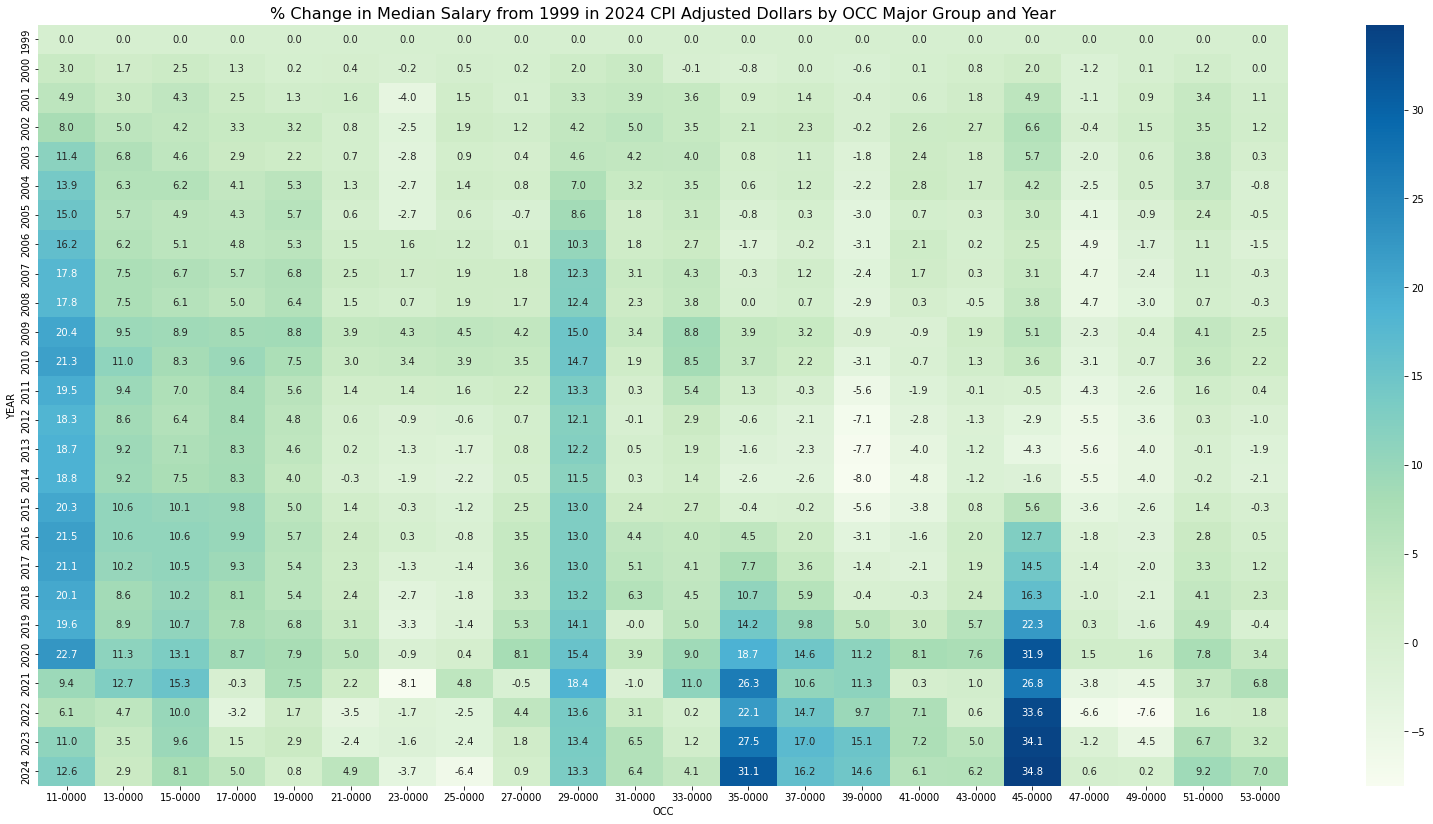

In [53]:
plt.figure(figsize=(28, 14))
sns.heatmap(relative_change_df, annot=True, cmap='GnBu', fmt='.1f')
plt.title('% Change in Median Salary from 1999 in 2024 CPI Adjusted Dollars by OCC Major Group and Year', fontsize=16)
plt.xlabel('OCC')
plt.ylabel('YEAR')
plt.show()

### Adjusted Trends

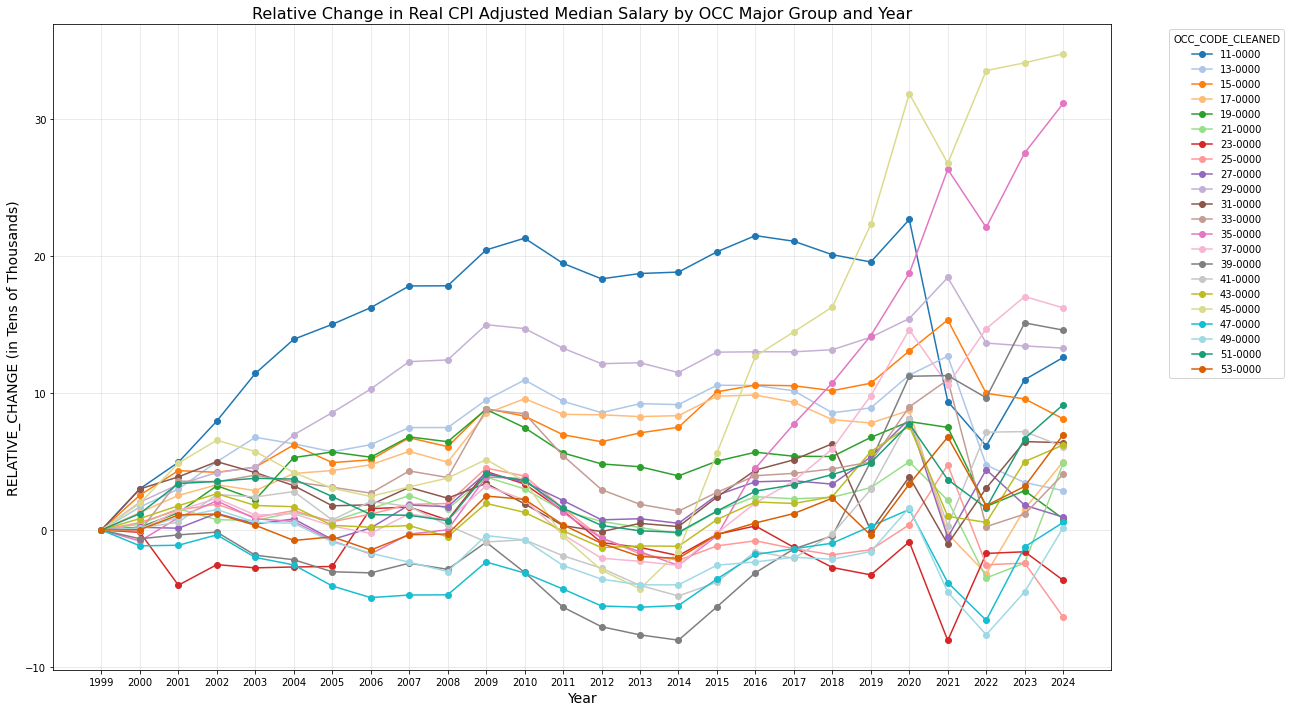

In [54]:
plt.figure(figsize=(18, 10))
for occ_code in relative_change_df.columns:
    plt.plot(relative_change_df.index, relative_change_df[occ_code], marker='o', label=occ_code)

plt.xlabel('Year', fontsize=14)
plt.ylabel('RELATIVE_CHANGE (in Tens of Thousands)', fontsize=14)
plt.title('Relative Change in Real CPI Adjusted Median Salary by OCC Major Group and Year', fontsize=16)
plt.legend(title='OCC_CODE_CLEANED', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



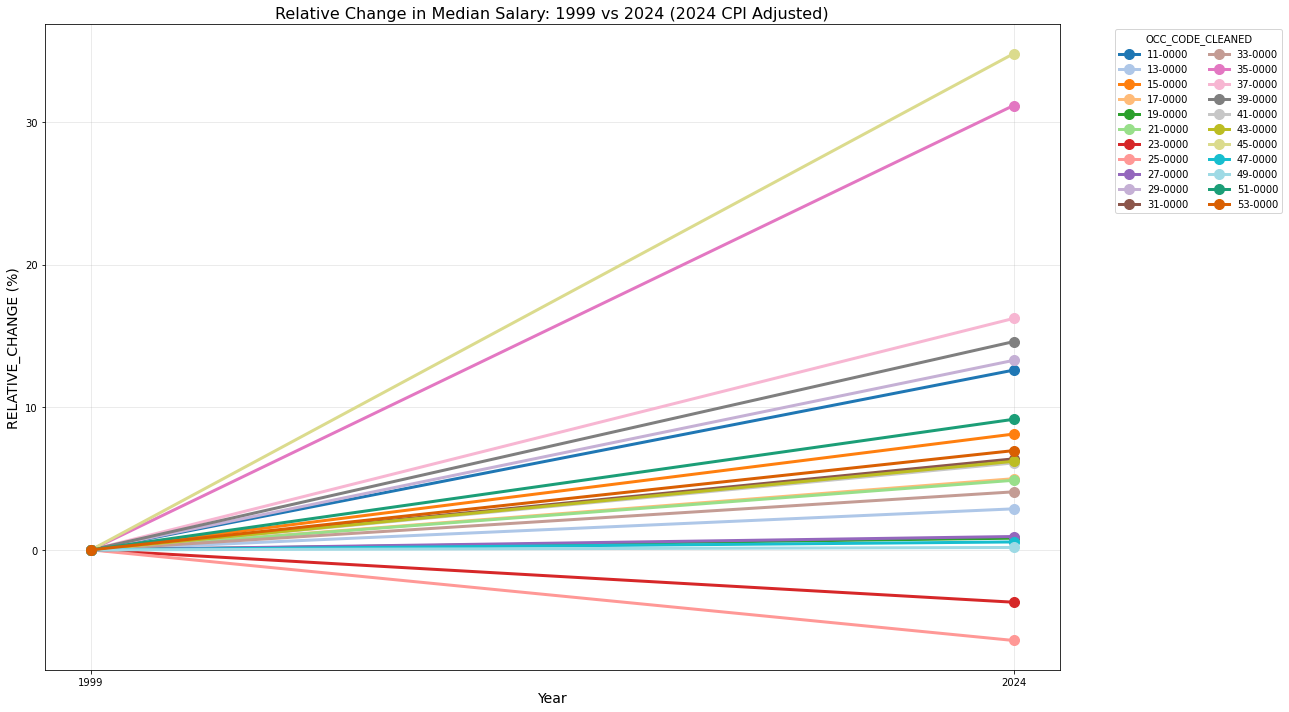

In [56]:

# Filter to show only 1999 and 2024 values
filtered_relative_change = relative_change_df.loc[['1999', '2024']]
plt.figure(figsize=(18, 10))


for occ_code in filtered_relative_change.columns:
    plt.plot(filtered_relative_change.index, filtered_relative_change[occ_code], marker='o', linewidth=3, markersize=10, label=occ_code)

plt.xlabel('Year', fontsize=14)
plt.ylabel('RELATIVE_CHANGE (%)', fontsize=14)

plt.title('Relative Change in Median Salary: 1999 vs 2024 (2024 CPI Adjusted)', fontsize=16)
plt.legend(title='OCC_CODE_CLEANED', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [57]:
df[((df['Year']== '1999-01-01') | (df['Year']== '2024-01-01')) & (df['OCC_Last4'] == '0000')][['Year', 'OCC_CODE_CLEANED','OCC_TITLE', 'REAL_A_MEDIAN']].sort_values(['OCC_CODE_CLEANED', 'Year'])

,Year,OCC_CODE_CLEANED,OCC_TITLE,REAL_A_MEDIAN
0,2024-01-01,00-0000,All Occupations,49500.000000
27508,1999-01-01,11-0000,Management Occupations,108430.657949
1,2024-01-01,11-0000,Management Occupations,122090.000000
27538,1999-01-01,13-0000,Business and Financial Operations Occupations,78658.363712
74,2024-01-01,13-0000,Business and Financial Operations Occupations,80920.000000
27565,1999-01-01,15-0000,Computer and Mathematical Occupations,97903.958089
132,2024-01-01,15-0000,Computer and Mathematical Occupations,105850.000000
27580,1999-01-01,17-0000,Architecture and Engineering Occupations,92687.686423
168,2024-01-01,17-0000,Architecture and Engineering Occupations,97310.000000
27613,1999-01-01,19-0000,"Life, Physical, and Social Science Occupations",78338.231516


In [59]:

# transpose so the rows are OCC codes and columns are years
filtered_relative_change_years = filtered_relative_change.T

# sort by 2024 values ascending
filtered_relative_change_sorted = filtered_relative_change_years.sort_values(by='2024', ascending=True)

# bring in OCC_TITLE once per OCC_CODE_CLEANED
occ_titles = (
    df[['OCC_CODE_CLEANED', 'OCC_TITLE']]
    .drop_duplicates(subset=['OCC_CODE_CLEANED'])
    .set_index('OCC_CODE_CLEANED')
)

filtered_relative_change_sorted = filtered_relative_change_sorted.merge(
    occ_titles,
    left_index=True,
    right_index=True,
    how='left'
)

filtered_relative_change_sorted


,1999,2024,OCC_TITLE
OCC_CODE_CLEANED,,,
25-0000,0.0,-6.350108,Educational Instruction and Library Occupations
23-0000,0.0,-3.668810,Legal Occupations
49-0000,0.0,0.168167,"Installation, Maintenance, and Repair Occupations"
47-0000,0.0,0.554663,Construction and Extraction Occupations
19-0000,0.0,0.819228,"Life, Physical, and Social Science Occupations"
27-0000,0.0,0.936099,"Arts, Design, Entertainment, Sports, and Media..."
13-0000,0.0,2.875265,Business and Financial Operations Occupations
33-0000,0.0,4.066366,Protective Service Occupations
21-0000,0.0,4.875358,Community and Social Service Occupations


>  
> **Conclusion** The most increased Salaries controlled for inflation are in Fishing/Farming, Food Prep, and Maintenance
>

### Linear Regression Slope and r2 on Salary

In [60]:
major_df = df[df['O_GROUP'] == 'major'][['Year', 'OCC_CODE_CLEANED','REAL_A_MEDIAN']].copy()
major_df = major_df[['Year', 'OCC_CODE_CLEANED','REAL_A_MEDIAN']].copy()

real_median_cross = pd.crosstab(index=broad_df['Year'], columns=major_df['OCC_CODE_CLEANED'],values=major_df['REAL_A_MEDIAN'],aggfunc='sum')

# Convert the Year index to string format 'YYYY'
real_median_cross.index = real_median_cross.index.strftime('%Y')

# Scale values to thousands for annotation
real_median_cross_scaled = real_median_cross / 1000


real_median_salaries_df = real_median_cross_scaled #Median Salaries for 2024 Dollars
real_median_salaries_df

OCC_CODE_CLEANED,11-0000,13-0000,15-0000,17-0000,19-0000,21-0000,23-0000,25-0000,27-0000,29-0000,...,35-0000,37-0000,39-0000,41-0000,43-0000,45-0000,47-0000,49-0000,51-0000,53-0000
Year,,,,,,,,,,,,,,,,,,,,,
1999,108.430658,78.658364,97.903958,92.687686,78.338232,54.855593,103.798157,63.235524,59.582251,73.347936,...,26.024864,31.655425,30.638534,35.308698,43.613304,27.267731,58.038084,58.132241,42.106799,39.960031
2000,111.694340,79.976864,100.399202,93.877171,78.501209,55.091125,103.623782,63.580696,59.700270,74.839398,...,25.814856,31.662822,30.442219,35.361069,43.978166,27.800614,57.368370,58.188179,42.611819,39.970214
2001,113.790706,81.010761,102.149396,95.026403,79.327467,55.708187,99.615595,64.160098,59.659500,75.783689,...,26.259394,32.106627,30.529646,35.508654,44.385817,28.598287,57.391482,58.667242,43.535311,40.399067
2002,117.061273,82.581217,102.027480,95.748866,80.872038,55.269245,101.172891,64.425558,60.309577,76.424687,...,26.579467,32.387185,30.590803,36.224116,44.770007,29.056031,57.833013,59.001532,43.601487,40.427299
2003,120.824941,83.982455,102.395173,95.354013,80.078277,55.238155,100.928975,63.813709,59.841335,76.702612,...,26.238124,32.000623,30.074107,36.160533,44.395110,28.829543,56.874842,58.460381,43.696109,40.098809
2004,123.530848,83.610407,103.985774,96.513145,82.481210,55.563143,100.996722,64.131756,60.063325,78.445991,...,26.187411,32.032666,29.973542,36.300367,44.354200,28.412593,56.559493,58.419347,43.673361,39.654747
2005,124.713496,83.153041,102.720352,96.711999,82.799608,55.199739,101.033515,63.617860,59.167823,79.634780,...,25.816642,31.744669,29.704400,35.568167,43.761376,28.097888,55.665627,57.625571,43.134837,39.761162
2006,126.034370,83.561192,102.922362,97.101560,82.502864,55.702273,105.412545,63.966567,59.671002,80.899809,...,25.571063,31.578629,29.679865,36.045394,43.702706,27.936737,55.173110,57.149692,42.582123,39.376013
2007,127.752199,84.542786,104.498394,98.007904,83.665284,56.235780,105.542319,64.420756,60.668678,82.364160,...,25.946829,32.028826,29.895588,35.917068,43.754069,28.125454,55.282631,56.765307,42.558851,39.820439


In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Initialize a list to store the regression results
regression_results = []

# Convert the Year index to numerical for regression
# real_median_salaries_df has its index as string years, convert to int
numeric_years = real_median_salaries_df.index.astype(int).values.reshape(-1, 1)

# Loop through each occupation code column in real_median_salaries_df
for occ_code in real_median_salaries_df.columns:
    # Extract the median salary data for the current occupation code
    y = real_median_salaries_df[occ_code].values

    # Create a DataFrame for convenience to handle NaN values across X and y
    temp_df = pd.DataFrame({'Year': numeric_years.flatten(), 'Salary': y})
    temp_df = temp_df.dropna() # Drop rows with NaN values (e.g., if salary data is missing)

    # If after dropping NaNs, there's not enough data for regression, skip
    if len(temp_df) < 2:
        regression_results.append({
            'OCC_CODE_CLEANED': occ_code,
            'Slope (Annual Change)': np.nan,
            'R-squared': np.nan
        })
        continue

    # Prepare X (independent variable - Year) and y (dependent variable - Salary)
    X_reg = temp_df['Year'].values.reshape(-1, 1)
    y_reg = temp_df['Salary'].values

    # Create and fit the linear regression model
    model = LinearRegression()
    model.fit(X_reg, y_reg)

    # Get the slope (coefficient) and R-squared value
    slope = model.coef_[0] # The slope represents the average annual change in median salary
    r_squared = r2_score(y_reg, model.predict(X_reg))

    # Store the results
    regression_results.append({
        'OCC_CODE_CLEANED': occ_code,
        'Slope (Annual Change)': slope,
        'R-squared': r_squared
    })

# Convert the results list to a DataFrame
regression_df = pd.DataFrame(regression_results)

# Merge with OCC_TITLE for better readability
occ_titles = df[['OCC_CODE_CLEANED', 'OCC_TITLE']].drop_duplicates(subset=['OCC_CODE_CLEANED'])
regression_df = regression_df.merge(occ_titles, on='OCC_CODE_CLEANED', how='left')

# Sort the results by 'Slope (Annual Change)' in descending order to see top growth occupations
regression_df_sorted = regression_df.sort_values(by='Slope (Annual Change)', ascending=False)

print("Linear Regression Results for Real Median Salaries (2024 CPI Adjusted):")
print("----------------------------------------------------------------------")
print(regression_df_sorted.to_string(index=False))

# Further analysis could involve filtering for high R-squared values to find reliable trends
# For example, filter for R-squared > 0.5 to only consider models with moderate to high predictive strength
print("\nOccupations with strong predictive trends (R-squared > 0.5) and highest growth:")
print("------------------------------------------------------------------------------")
high_r_squared_growth = regression_df_sorted[regression_df_sorted['R-squared'] > 0.5]
print(high_r_squared_growth.to_string(index=False))


Linear Regression Results for Real Median Salaries (2024 CPI Adjusted):
----------------------------------------------------------------------
OCC_CODE_CLEANED  Slope (Annual Change)  R-squared                                                  OCC_TITLE
         15-0000               0.363362   0.728493                      Computer and Mathematical Occupations
         29-0000               0.362963   0.673749         Healthcare Practitioners and Technical Occupations
         11-0000               0.362922   0.159819                                     Management Occupations
         45-0000               0.340678   0.589868                 Farming, Fishing, and Forestry Occupations
         35-0000               0.274768   0.620006           Food Preparation and Serving Related Occupations
         37-0000               0.180105   0.526092  Building and Grounds Cleaning and Maintenance Occupations
         39-0000               0.153107   0.328586                      Personal Care a

## ML for Predicting Salary

In [62]:
# Prepare percent_of_market_df for merging
market_share_long = percent_of_market_df.reset_index()
market_share_long = market_share_long.melt(id_vars=['Year'], var_name='OCC_CODE_CLEANED', value_name='Market_Share_Percent')

# Convert Year to datetime object for merging consistency
market_share_long['Year'] = pd.to_datetime(market_share_long['Year'], format='%Y')

# Filter df for major occupation groups and exclude '00-0000'
major_occ_df = df[(df['O_GROUP'] == 'major') & (df['OCC_CODE_CLEANED'] != '00-0000')].copy()

# Merge with market share percentages
merged_df = pd.merge(major_occ_df,
                     market_share_long,
                     on=['Year', 'OCC_CODE_CLEANED'],
                     how='left')

# Display the head of the merged DataFrame to verify
display(merged_df.head())


,Year,OCC_CODE_CLEANED,OCC_TITLE,O_GROUP,TOT_EMP,EMP_PRSE,H_MEAN,A_MEAN,MEAN_PRSE,H_PCT10,...,HOURLY,ONE_OR_THREE,CPI,REAL_A_MEAN,REAL_A_MEDIAN,REAL_H_MEDIAN,REAL_H_MEAN,OCC_2DIGIT,OCC_Last4,Market_Share_Percent
0,2024-01-01,11-0000,Management Occupations,major,10966830.0,0.2,68.15,141760.0,0.2,27.41,...,nan,NaN,313.698167,141760.0,122090.0,58.70,68.15,11,0000,7.112664
1,2024-01-01,13-0000,Business and Financial Operations Occupations,major,10351440.0,0.2,45.04,93680.0,0.4,22.75,...,nan,NaN,313.698167,93680.0,80920.0,38.90,45.04,13,0000,6.713546
2,2024-01-01,15-0000,Computer and Mathematical Occupations,major,5192890.0,0.4,56.16,116810.0,0.3,26.01,...,nan,NaN,313.698167,116810.0,105850.0,50.89,56.16,15,0000,3.367909
3,2024-01-01,17-0000,Architecture and Engineering Occupations,major,2567210.0,0.4,49.99,103980.0,0.3,26.71,...,nan,NaN,313.698167,103980.0,97310.0,46.79,49.99,17,0000,1.664994
4,2024-01-01,19-0000,"Life, Physical, and Social Science Occupations",major,1446770.0,0.4,43.12,89690.0,0.4,21.87,...,nan,NaN,313.698167,89690.0,78980.0,37.97,43.12,19,0000,0.938319


In [63]:

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Drop rows with NaN values that might have resulted from merging or initial data cleaning
merged_df.dropna(subset=['REAL_A_MEDIAN', 'TOT_EMP', 'Market_Share_Percent'], inplace=True)

# One-hot encode OCC_CODE_CLEANED
X_encoded = pd.get_dummies(merged_df, columns=['OCC_CODE_CLEANED'], drop_first=True)

# Define features (X) and target (y)
y = X_encoded['REAL_A_MEDIAN']

# Features: 'Year' (numerical year), 'TOT_EMP', 'Market_Share_Percent', and one-hot encoded OCC codes
# Extract just the year from the datetime object
X_encoded['Numeric_Year'] = X_encoded['Year'].dt.year

# Select the feature columns
feature_cols = ['Numeric_Year', 'TOT_EMP', 'Market_Share_Percent'] + \
               [col for col in X_encoded.columns if col.startswith('OCC_CODE_CLEANED_')]

X = X_encoded[feature_cols]

# Time-based train-test split
# Train: 1999-2016, Test: 2017-2024
X_train = X[X['Numeric_Year'] <= 2016]
y_train = y[X['Numeric_Year'] <= 2016]

X_test = X[X['Numeric_Year'] >= 2017]
y_test = y[X['Numeric_Year'] >= 2017]

# Ensure feature columns are consistent between train and test after splitting
# This is important if some OCC codes only appear in one split, get_dummies would handle this usually but with explicit split, we must re-align.
# Let's re-run get_dummies on the full dataset and then split to ensure all columns exist.

# Re-do one-hot encoding on the full dataset to ensure consistent columns for train and test
X_full_encoded = pd.get_dummies(merged_df[['Year', 'TOT_EMP', 'Market_Share_Percent', 'OCC_CODE_CLEANED']], 
                                  columns=['OCC_CODE_CLEANED'], drop_first=True)
X_full_encoded['Numeric_Year'] = X_full_encoded['Year'].dt.year

# Align y with X_full_encoded
y_full = merged_df['REAL_A_MEDIAN']

# Select the final feature columns after full encoding
final_feature_cols = ['Numeric_Year', 'TOT_EMP', 'Market_Share_Percent'] + \
                     [col for col in X_full_encoded.columns if col.startswith('OCC_CODE_CLEANED_')]

X_final = X_full_encoded[final_feature_cols]

# Time-based train-test split on the consistent X and y
X_train = X_final[X_final['Numeric_Year'] <= 2016]
y_train = y_full[X_final['Numeric_Year'] <= 2016]

X_test = X_final[X_final['Numeric_Year'] >= 2017]
y_test = y_full[X_final['Numeric_Year'] >= 2017]

# Drop the Numeric_Year from X_train and X_test for model training
# As it's already used for splitting, but we want to use the Year column as a feature.
# Let's adjust feature_cols to reflect using 'Numeric_Year' itself as a feature, not just for splitting.

# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")
print("Intercept:", model.intercept_)

# Display coefficients (slope) for each feature
coefficients = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model.coef_})
display(coefficients.sort_values(by='Coefficient', ascending=False))


R-squared: 0.9859
RMSE: 3219.76
Intercept: -188591.14393209192


,Feature,Coefficient
2,Market_Share_Percent,1403.990492
0,Numeric_Year,155.942009
1,TOT_EMP,-0.001062
4,OCC_CODE_CLEANED_15-0000,-20559.654832
8,OCC_CODE_CLEANED_23-0000,-21014.001990
5,OCC_CODE_CLEANED_17-0000,-26382.209110
3,OCC_CODE_CLEANED_13-0000,-40259.408191
6,OCC_CODE_CLEANED_19-0000,-42542.605852
11,OCC_CODE_CLEANED_29-0000,-44252.642985
9,OCC_CODE_CLEANED_25-0000,-60748.933370


- You built a linear regression model for `REAL_A_MEDIAN` using:
    - `Numeric_Year`
    - `TOT_EMP`
    - `Market_Share_Percent`
    - one-hot encoded major OCC codes

- Evaluation shows R² and RMSE on test set. If R² is moderate (e.g., 0.4, 0.7) it means the model captures a meaningful part of variance but not all; if low, signal you need more features / non-linear model.

- Practical use cases:
    - forecast inflation-adjusted median salary for major occupation groups if you have next-year `TOT_EMP` and `Market_Share_Percent` estimates
    - quantify which features move salary most via coefficients (if `Numeric_Year` coefficient positive → trend growth over time; if `TOT_EMP` positive → higher employment tied to higher salary)
    - simulate “what if”: change tech share from 7% to 9% and see predicted effect on `REAL_A_MEDIAN` for OCC codes (through model intercept + coefficients)

- Limitations to mention:
    - this is a global linear model, so it may miss non-linear dynamics in each occupation
    - one-hot OCC codes express fixed offsets, but interactions (e.g., technology growth + automation) are not explicitly modeled
    - training period pre-2017/2016 split; recent shocks (COVID inflation, labor supply) may require retraining or more robust models (tree-based, time series, panel models)

- Next steps for real-life deployment:
    - add macro inputs (CPI change, GDP, unemployment)
    - test with unseen years and hold-out by occupation group
    - use cross-validation / regularization (Ridge/Lasso) to avoid overfitting with many OCC dummy variables.

In [67]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error
import numpy as np

# existing model, X_train, X_test, y_train, y_test are defined already

r2_train = model.score(X_train, y_train)
r2_test = model.score(X_test, y_test)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Train R²: {r2_train:.4f}, Test R²: {r2_test:.4f}")
print(f"Train RMSE: {rmse_train:.2f}, Test RMSE: {rmse_test:.2f}")

# time-series CV
tss = TimeSeriesSplit(n_splits=5)
cv_r2 = cross_val_score(model, X_final, y_full, cv=tss, scoring='r2')
print("CV R²:", np.round(cv_r2, 4))
print("CV R² mean:", np.mean(cv_r2).round(4), "std:", np.std(cv_r2).round(4))

# residual check for test
resid_test = y_test - y_test_pred
print("Test resid mean:", resid_test.mean(), "std:", resid_test.std())

Train R²: 0.9950, Test R²: 0.9859
Train RMSE: 1986.02, Test RMSE: 3219.76
CV R²: [0.9827 0.9877 0.9921 0.9943 0.979 ]
CV R² mean: 0.9872 std: 0.0057
Test resid mean: 104.27717321900595 std: 3227.254280140546
